In [136]:
# import necessary packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob

In [2]:
# mount google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [118]:
# define tercile cutoff helper functions

# get the tercile cutoffs of a dataframe
def get_tercile_cutoffs(df):
    return df.quantile([0.33, 0.66])

# Assign the Tercile Category for both predicted_precip and precip
def assign_tercile_category(value, lower_cutoff, upper_cutoff):
    if value <= lower_cutoff:
        return 'Low'
    elif value <= upper_cutoff:
        return 'Medium'
    else:
        return 'High'

In [130]:
def compute_tercile_seasonal_df(seasonal_file_path):
    """Takes a file path to seasonal csv file and computes tercile
    agreement for each month of prediction and season.

    Requires helper functions get_tercile_cutoffs and assign_tercile_category,
    which are defined above.

    Arguments
    ---------
    seasonal_file_path (str): file path to seasonal csv file
    make sure that the path provided is a path to the actual file:
    /data/csv/{some_region}_{some_model}_merged_seasonal.csv

    The csv file has the following columns:
    'date_of_prediction' - model's date of prediction as YYYY-MM-DD
    'season' - season that the model is predicting, i.e. JJA, JAS, SON, DJF, MAM
    'predicted_precip' - predicted precipitation from model
    'precip' - actual precipitation from CHIRPS
    'model' - model name, i.e. NCEP, CFSv2, ECMWF, GFS
    'region' - region name, i.e. eastern_east_africa, west_africa, etc.

    Returns
    -------
    dataframe with tercile agreement for each month of prediction and season

    The resulting dataframe has the following columns:
    'year_of_prediction' - year of prediction as YYYY
    'season' - season that the model is predicting, i.e. JJA, JAS, SON, DJF, MAM
    'month_of_prediction' - month of prediction as MM
    'predicted_precip' - predicted precipitation from model
    'precip' - actual precipitation from CHIRPS
    f'{model}_tercile_class' - tercile class (low/medium/high) of predicted precipitation from model,
                                column name changes dynamically
    'chirps_tercile_class' - tercile class of actual precipitation from CHIRPS
    'agreement' - 1 if terciles agree, 0 otherwise
    'model' - model name, i.e. NCEP, CFSv2, ECMWF, GFS
    'region' - region name, i.e. eastern_east_africa, west_africa, etc.
    """

    # open seasonal file
    df = pd.read_csv(seasonal_file_path, index_col=0)

    # Convert 'date_of_prediction' to datetime
    df['date_of_prediction'] = pd.to_datetime(df['date_of_prediction'])
    df['month_of_prediction'] = df['date_of_prediction'].dt.month
    df['year_of_prediction'] = df['date_of_prediction'].dt.year



    # Iterate over every unique combination of month_of_prediction and season over all years
    for (month, season), group in df.groupby(['month_of_prediction', 'season']):

        model = df['model'].iloc[0]
        region = df['region'].iloc[0]

        cutoffs = get_tercile_cutoffs(group[['predicted_precip', 'precip']])

        # extract cutoffs for predicted precip and precip
        lower_cutoff_predicted = cutoffs.loc[0.33, 'predicted_precip']
        upper_cutoff_predicted = cutoffs.loc[0.66, 'predicted_precip']

        lower_cutoff_precip = cutoffs.loc[0.33, 'precip']
        upper_cutoff_precip = cutoffs.loc[0.66, 'precip']

        # assign tercile categories for predicted_precip and precip
        group[f'{model}_tercile_class'] = group['predicted_precip'].apply(assign_tercile_category, args=(lower_cutoff_predicted, upper_cutoff_predicted))
        group['chirps_tercile_class'] = group['precip'].apply(assign_tercile_category, args=(lower_cutoff_precip, upper_cutoff_precip))

        # calculate agreement, 1 if terciles agree, 0 otherwise
        group['agreement'] = (group[f'{model}_tercile_class'] == group['chirps_tercile_class']).astype(int)

        # Update the DataFrame with the new columns
        df.loc[group.index, f'{model}_tercile_class'] = group[f'{model}_tercile_class']
        df.loc[group.index, 'chirps_tercile_class'] = group['chirps_tercile_class']
        df.loc[group.index, 'agreement'] = group['agreement']
        df.loc[group.index, 'model'] = model
        df.loc[group.index, 'region'] = region

    # Select the desired columns for the final DataFrame
    final_columns = ['year_of_prediction', 'season', 'month_of_prediction', 'predicted_precip', 'precip', f'{model}_tercile_class', 'chirps_tercile_class', 'agreement', 'model', 'region']
    final_df = df[final_columns]

    return final_df


In [138]:
# Initialize an empty dictionary to store DataFrames
dfs_dict = {}

# initiate file list
list_of_files = glob.glob('/content/drive/My Drive/capstone_data/csv/*')

# Loop over all files
for f in list_of_files:
    # Generate the DataFrame
    df = compute_tercile_seasonal_df(f)

    # Store the DataFrame in the dictionary with the year as key
    dfs_dict[f] = df

# Concatenate all DataFrames in the dictionary into one DataFrame
final_df = pd.concat(dfs_dict.values(), ignore_index=True)

# Now final_df contains all concatenated data

In [142]:
# subset the final_df by tercile class, low, medium, and high for plotting

# subset by chirps tercile class = low
region_model_df_low = final_df.query('chirps_tercile_class == "Low"')

# compute agreement rates
region_model_df_low = region_model_df_low.groupby(['month_of_prediction', 'season', 'model', 'region'])[['agreement']].mean().reset_index()

# subset by chirps tercile class = medium
region_model_df_medium = df.query('chirps_tercile_class == "Medium"')

# compute agreement rates
region_model_df_medium = region_model_df_medium.groupby(['month_of_prediction', 'season', 'model', 'region'])[['agreement']].mean().reset_index()

# subset by chirps tercile class = High
region_model_df_high = final_df.query('chirps_tercile_class == "High"')

# compute agreement rates
region_model_df_high = region_model_df_high.groupby(['month_of_prediction', 'season', 'model', 'region'])[['agreement']].mean().reset_index()

In [146]:
region_model_df_high

,month_of_prediction,season,model,region,agreement
0,1,AMJ,CCSM4,eastern_ukraine,0.454545
1,1,AMJ,CESM1,eastern_ukraine,0.400000
2,1,AMJ,CMCC,eastern_ukraine,0.500000
3,1,AMJ,CanESM5,eastern_ukraine,0.300000
4,1,AMJ,DWD,eastern_ukraine,0.272727
...,...,...,...,...,...
1180,12,MJJ,GFDL,south_sudan,0.363636
1181,12,MJJ,JMA,south_sudan,0.200000
1182,12,MJJ,METEO,south_sudan,0.400000
1183,12,MJJ,NASA,south_sudan,0.363636


In [147]:
region_model_df_low

,month_of_prediction,season,model,region,agreement
0,1,AMJ,CCSM4,eastern_ukraine,0.363636
1,1,AMJ,CESM1,eastern_ukraine,0.400000
2,1,AMJ,CMCC,eastern_ukraine,0.333333
3,1,AMJ,CanESM5,eastern_ukraine,0.444444
4,1,AMJ,DWD,eastern_ukraine,0.400000
...,...,...,...,...,...
1180,12,MJJ,GFDL,south_sudan,0.454545
1181,12,MJJ,JMA,south_sudan,0.500000
1182,12,MJJ,METEO,south_sudan,0.300000
1183,12,MJJ,NASA,south_sudan,0.272727


In [151]:
# for predictions made in January for the AMJ season in eastern ukraine, CESM1 agrees with chirps 40% of the time for the upper tercile

<ipython-input-164-552bf4c579b8>:14: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(10, 6))


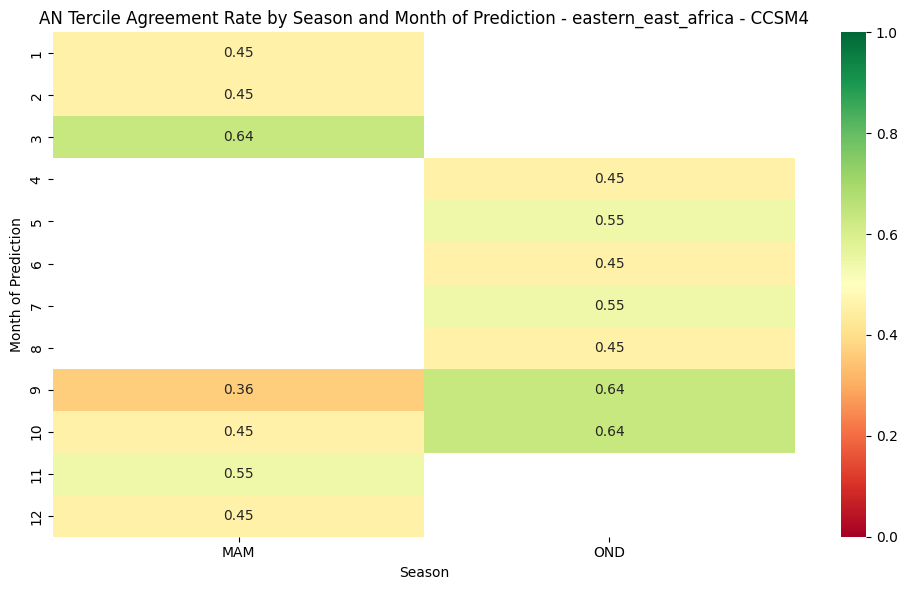

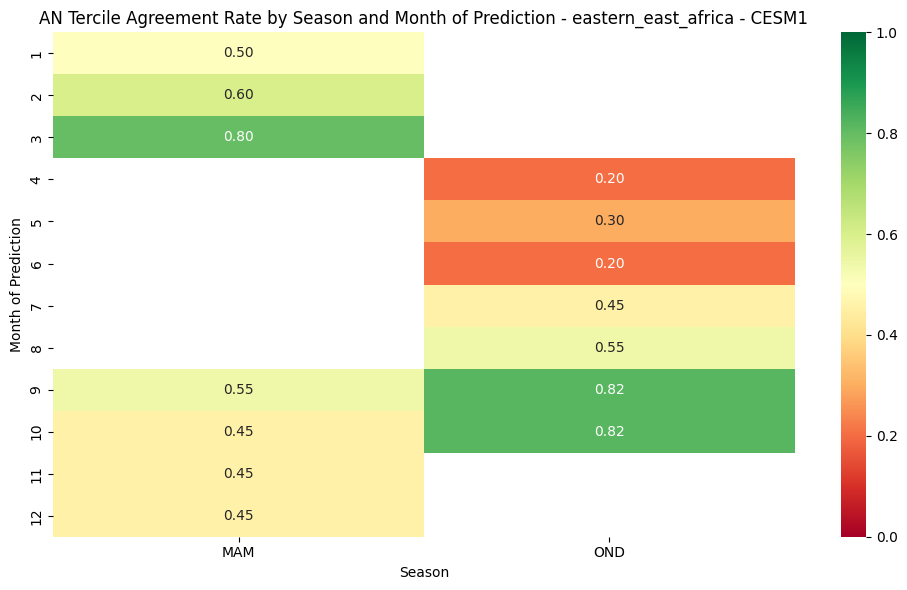

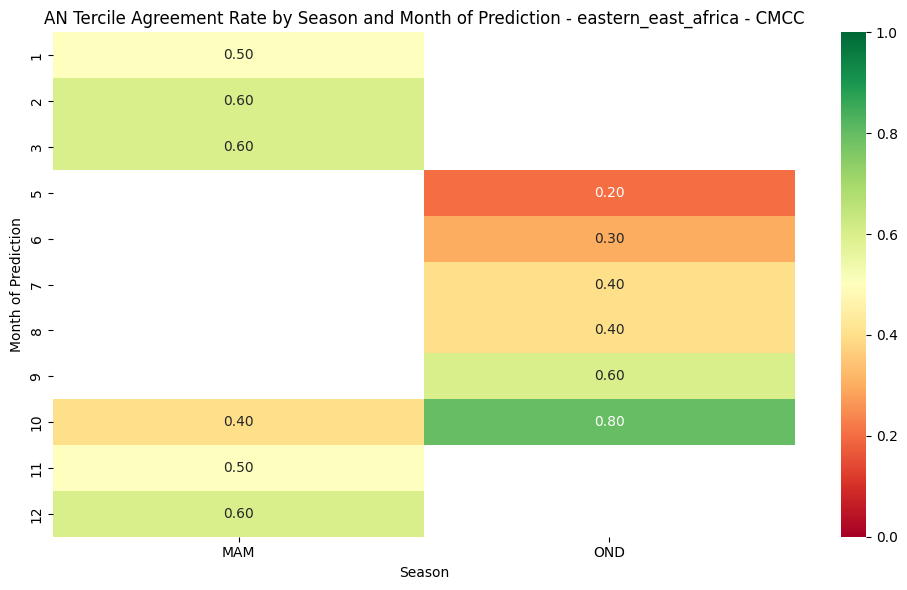

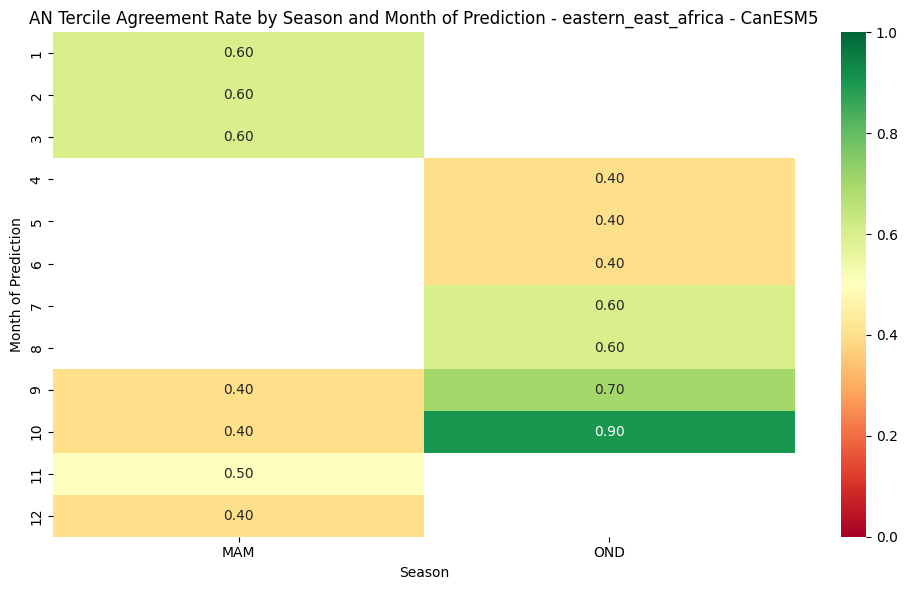

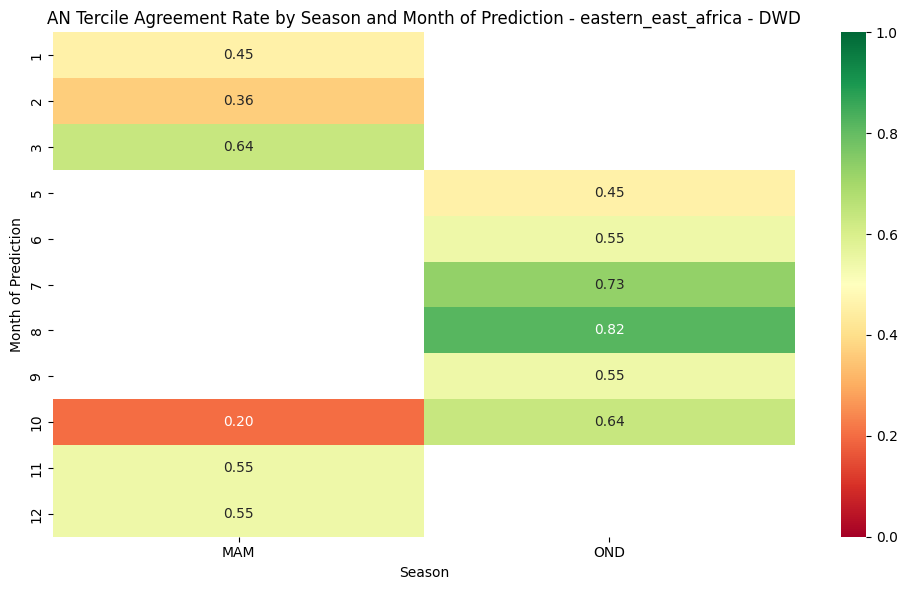

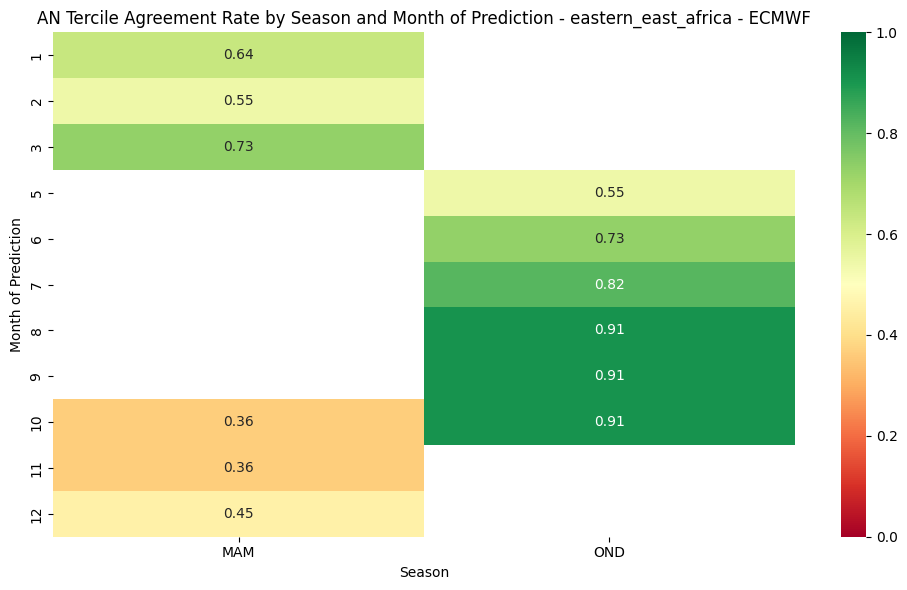

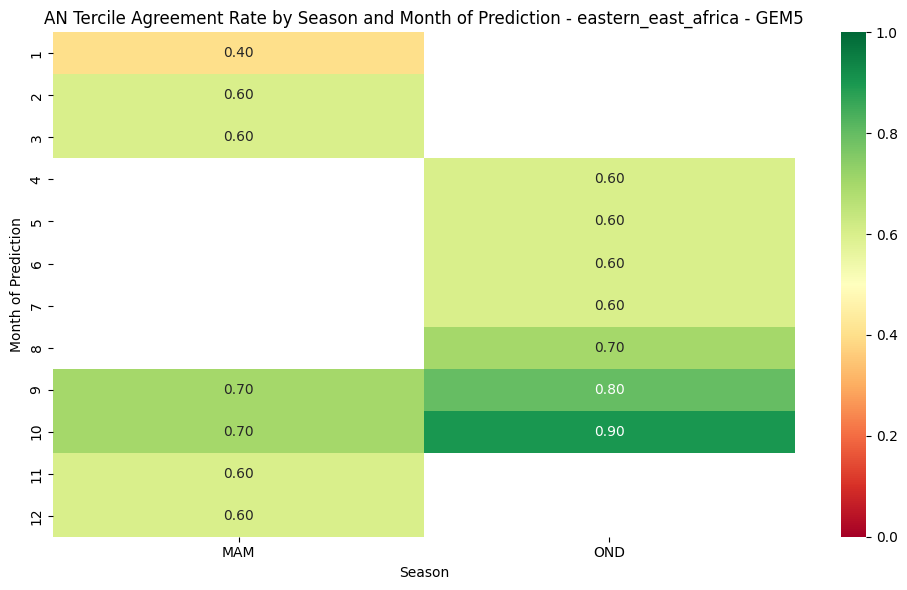

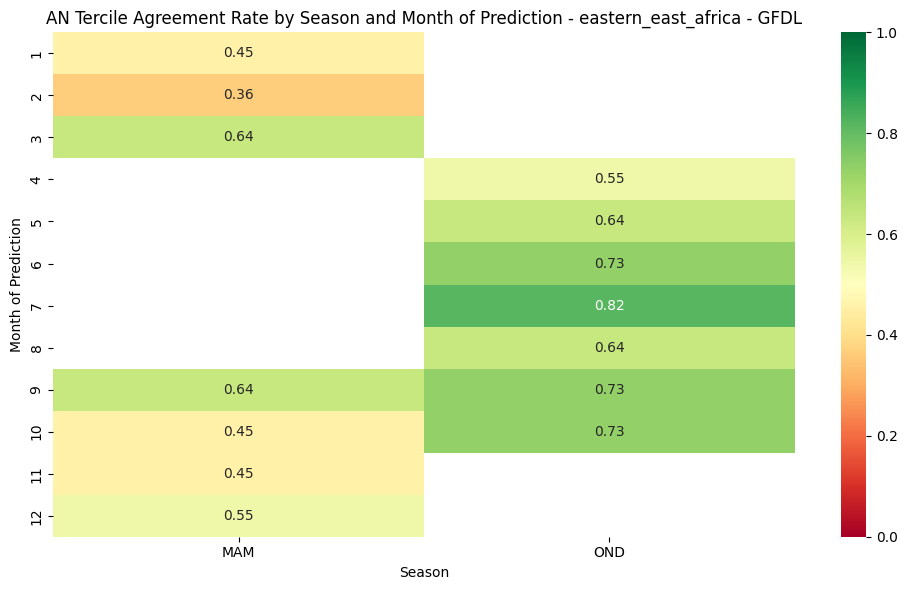

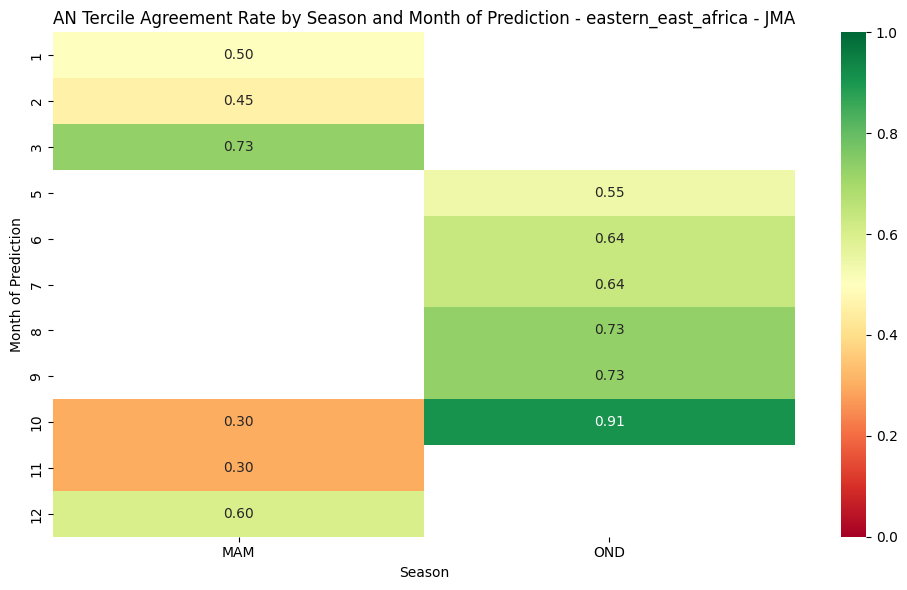

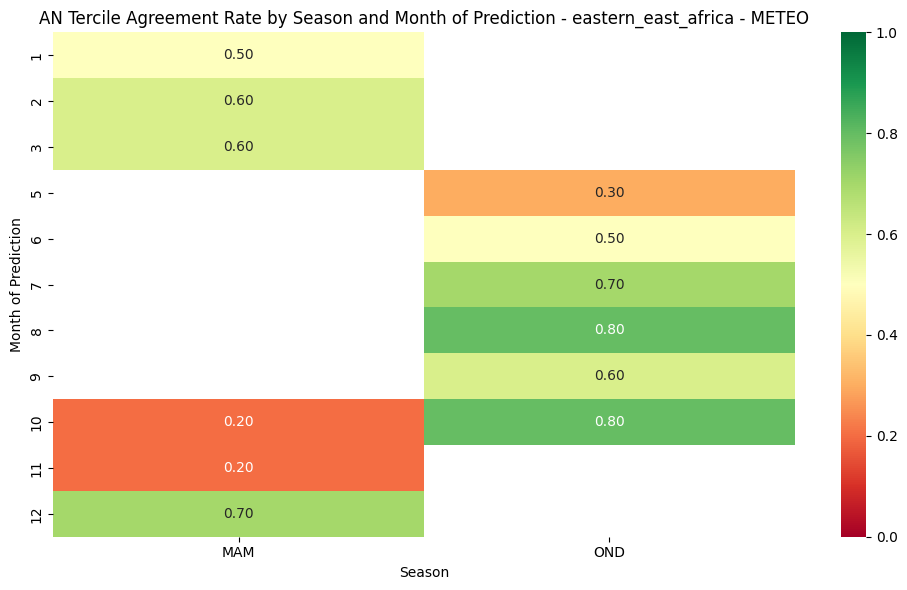

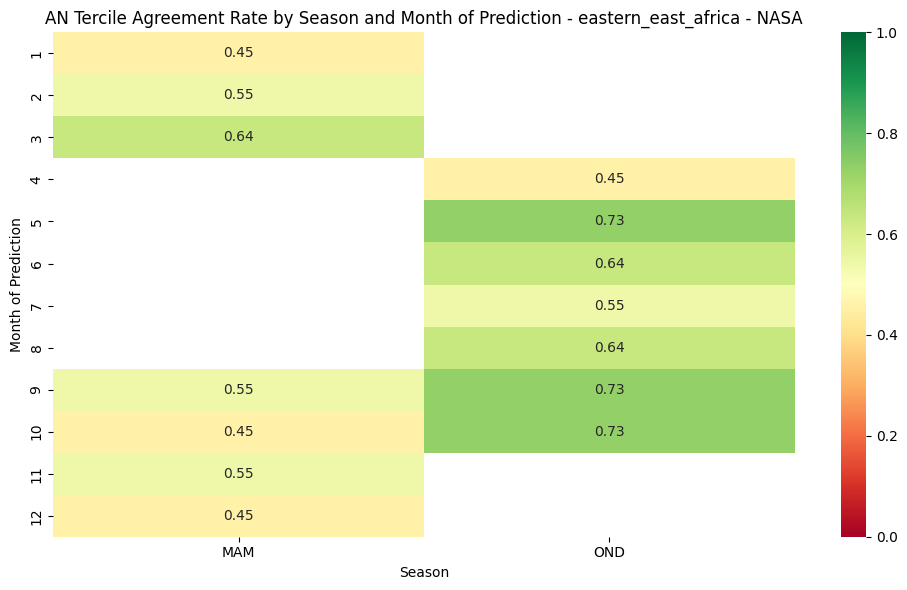

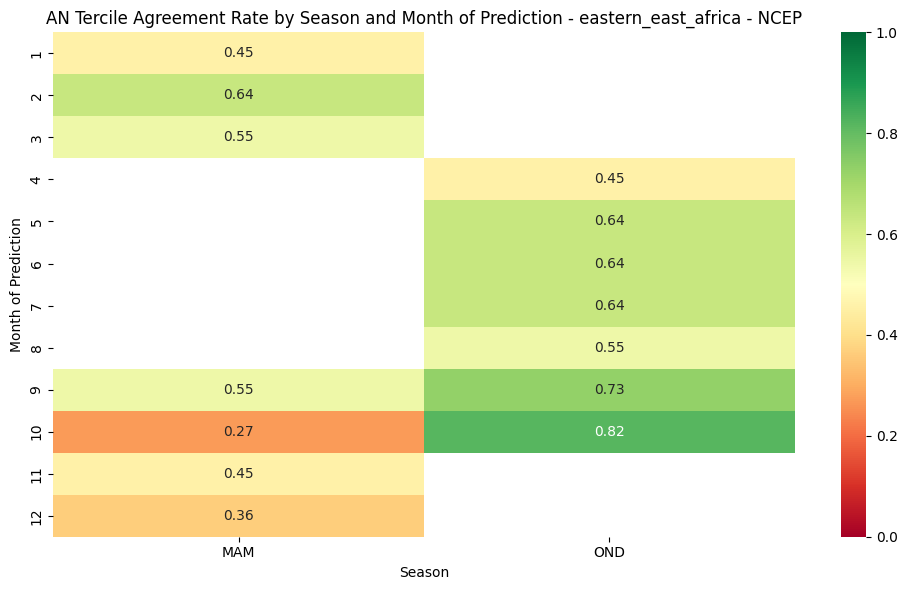

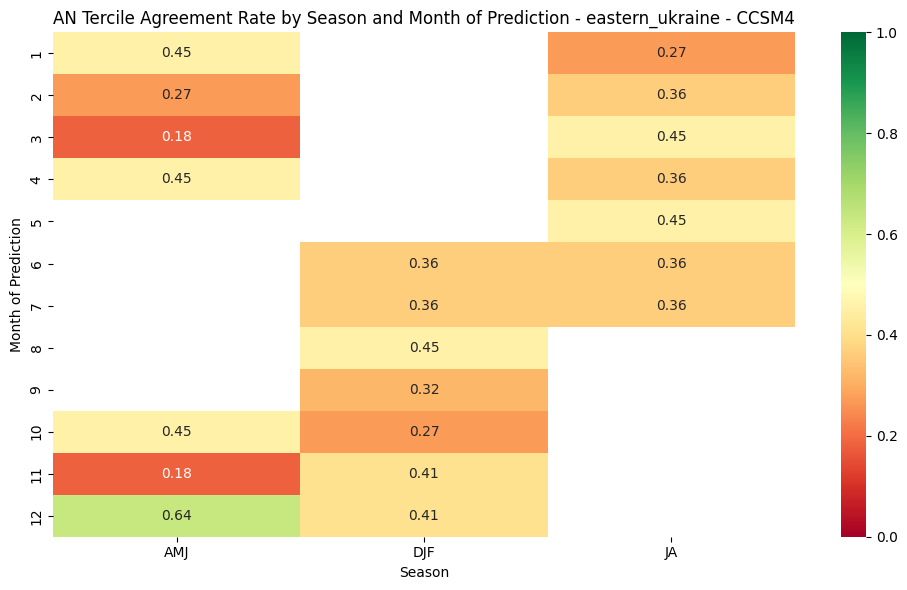

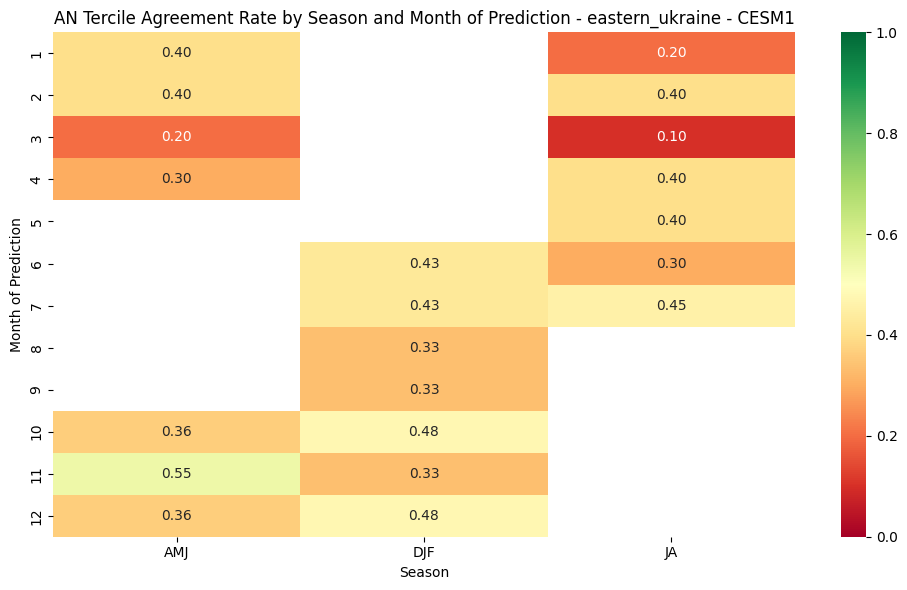

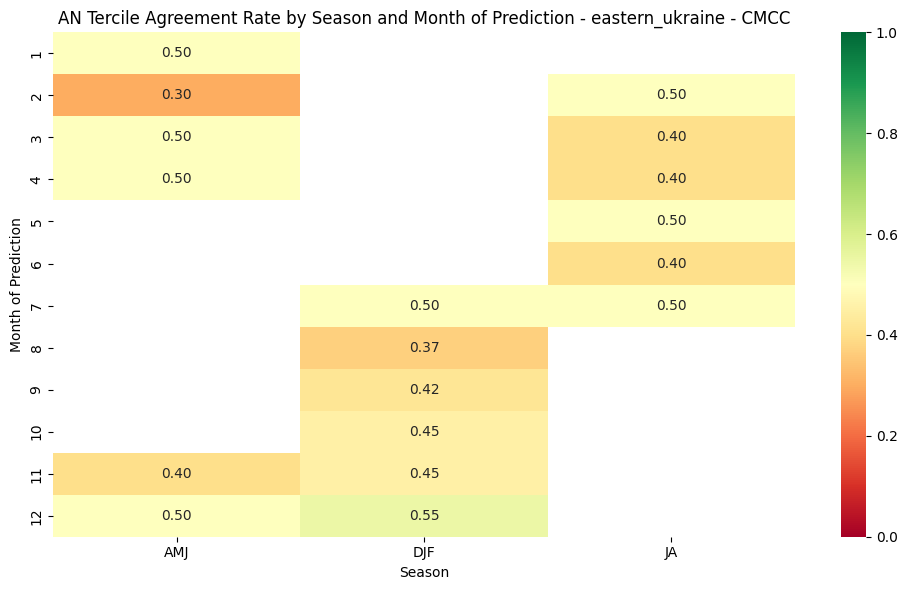

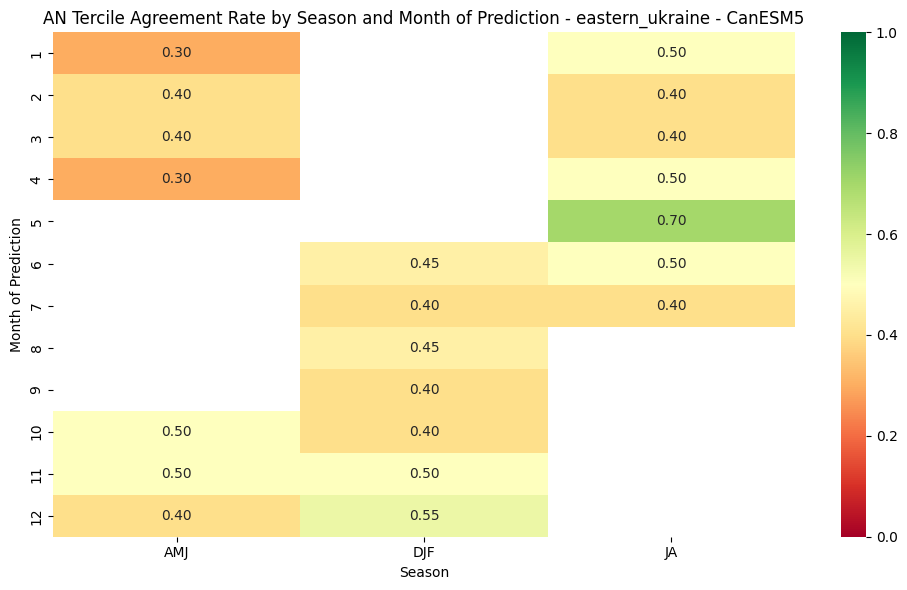

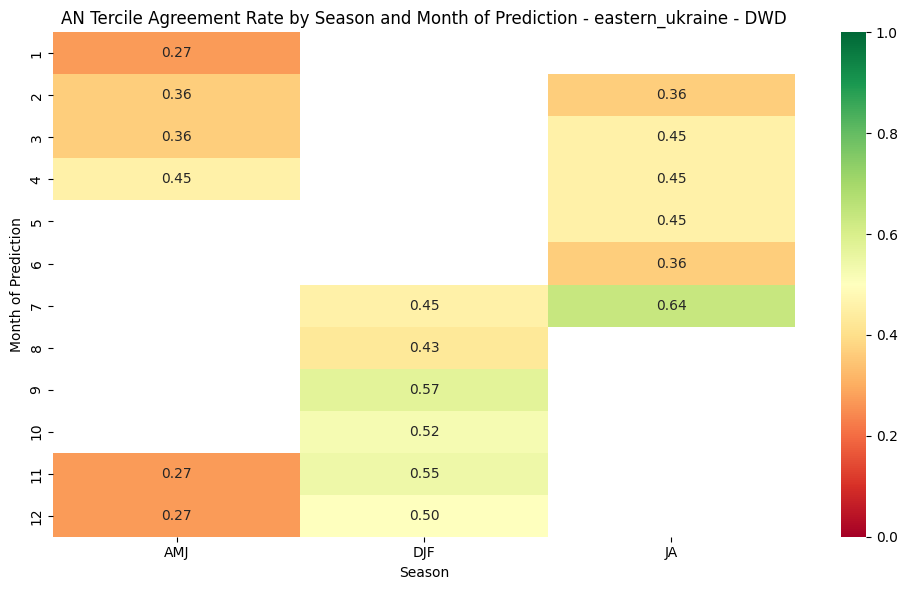

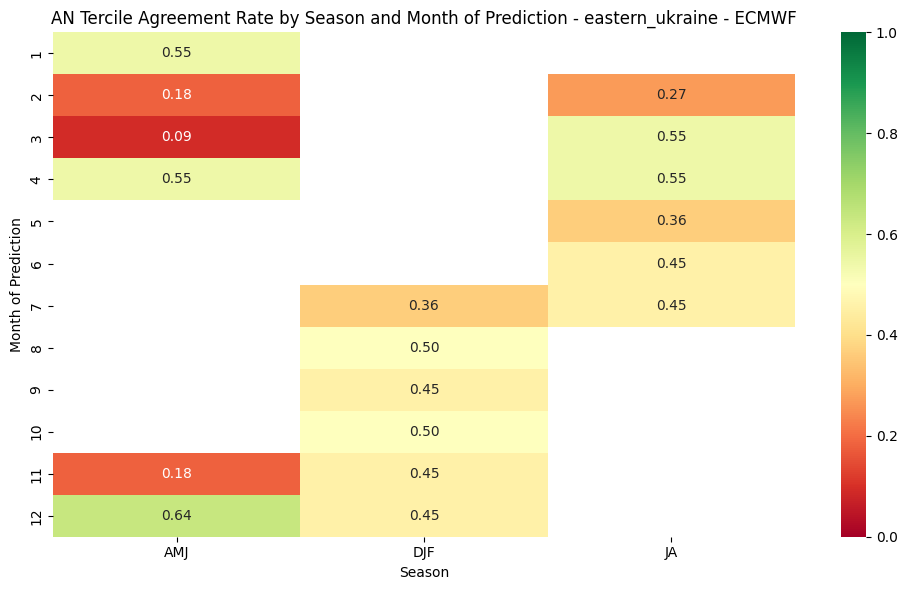

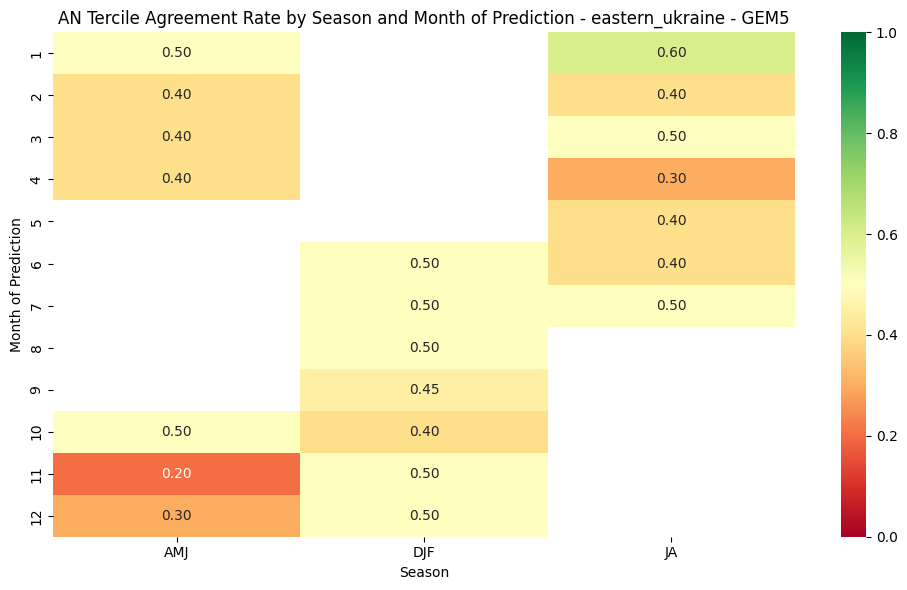

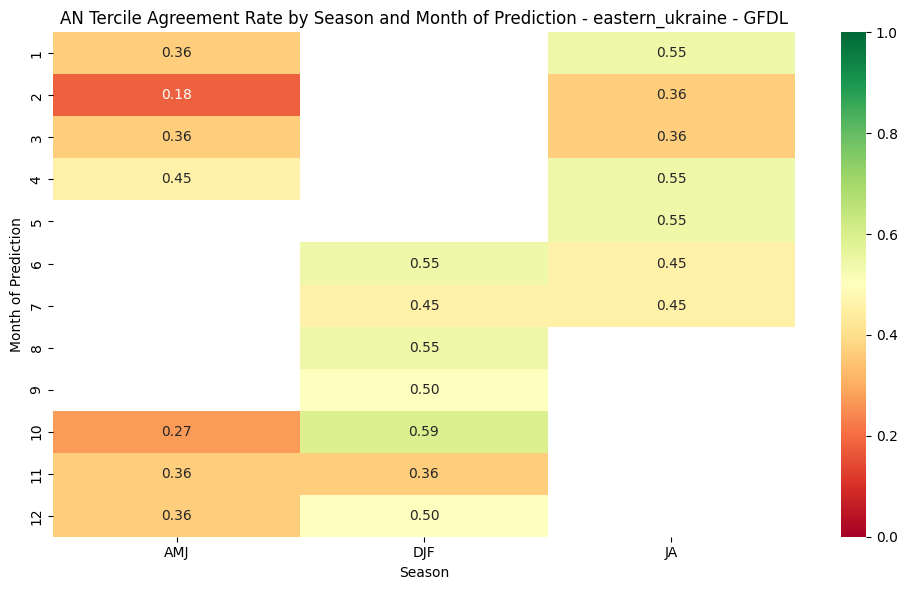

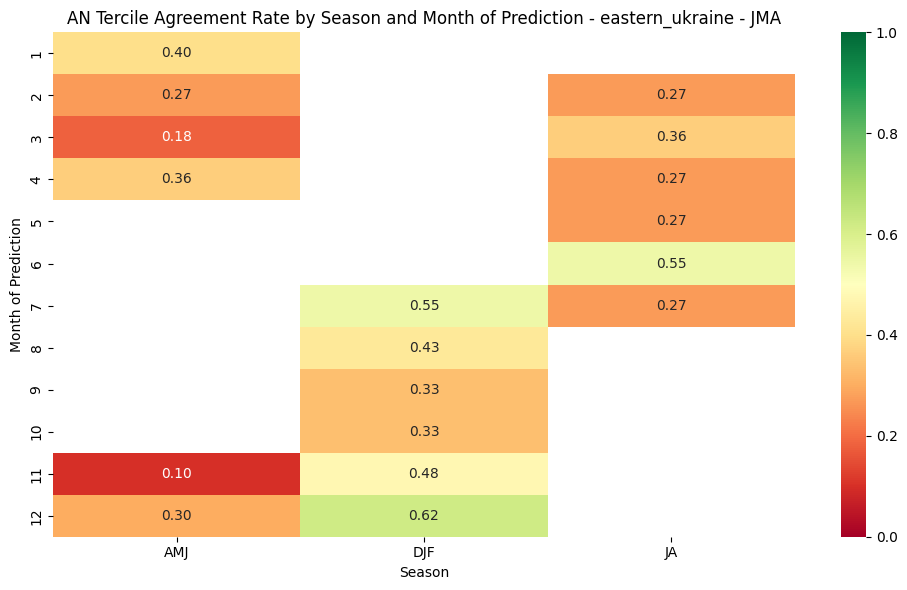

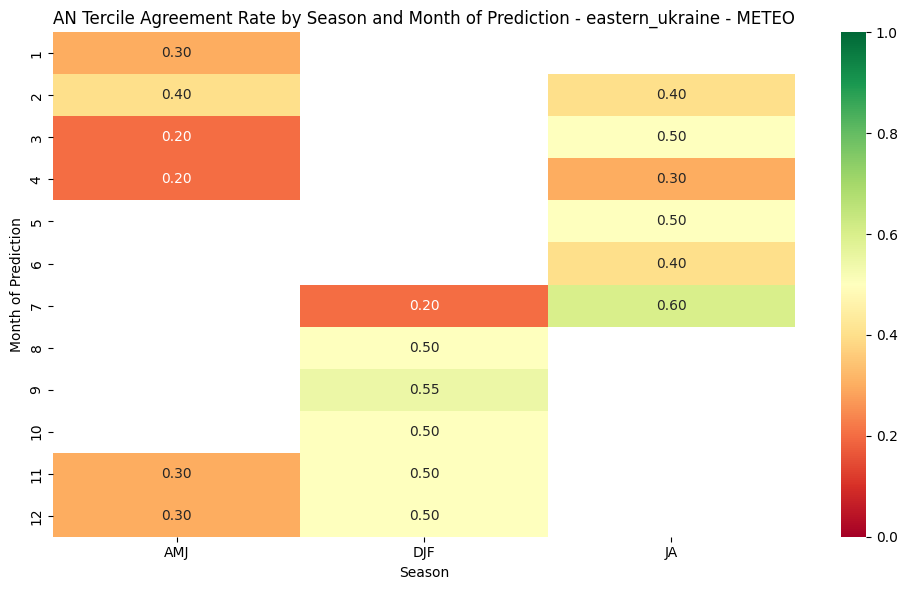

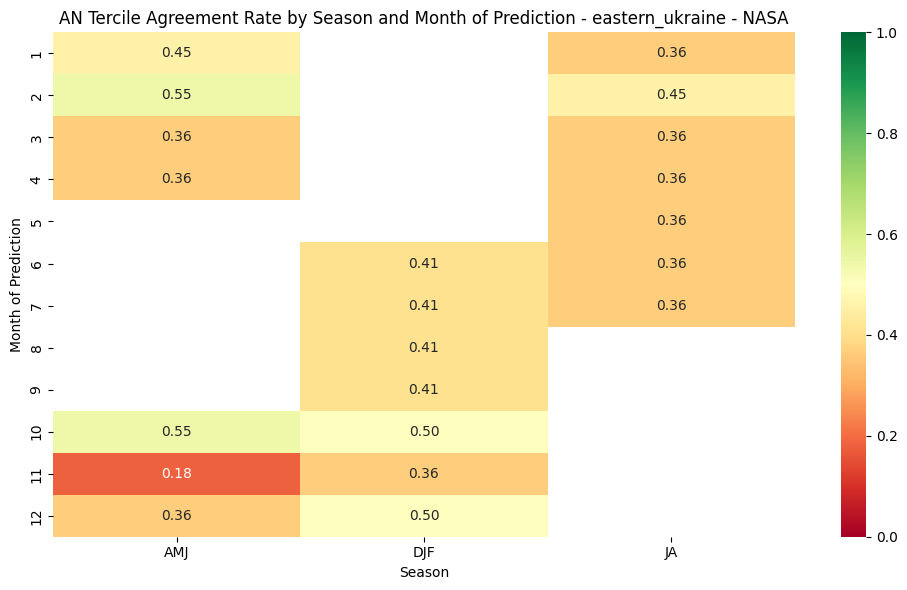

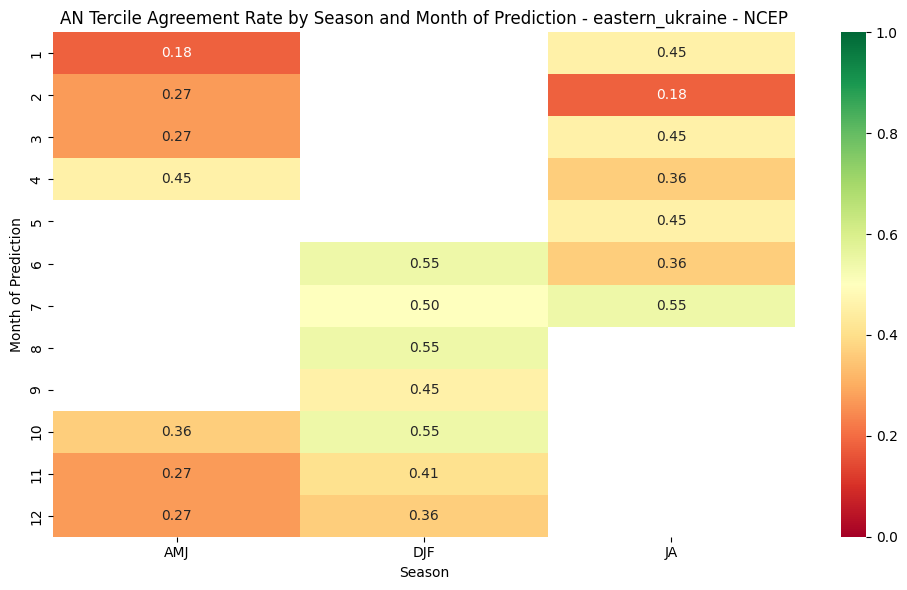

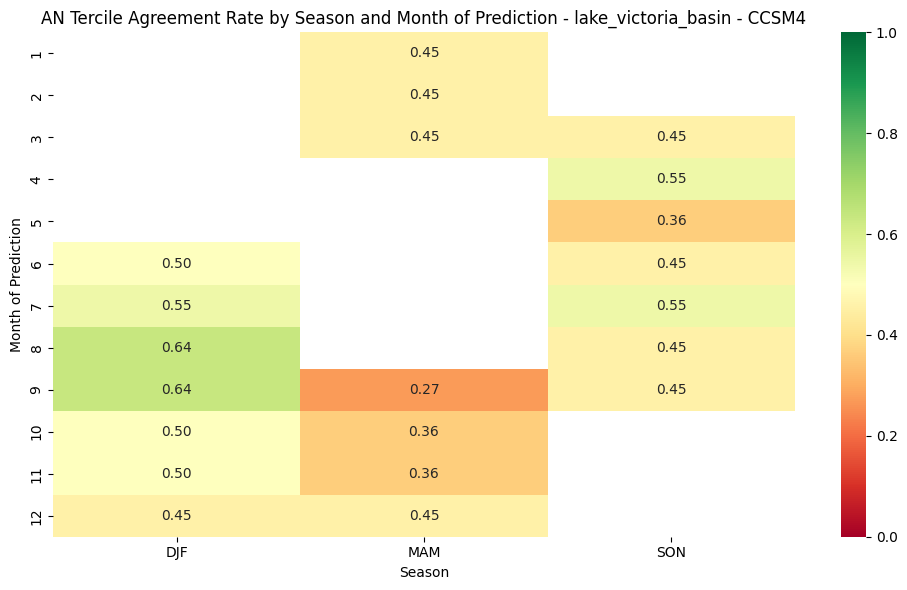

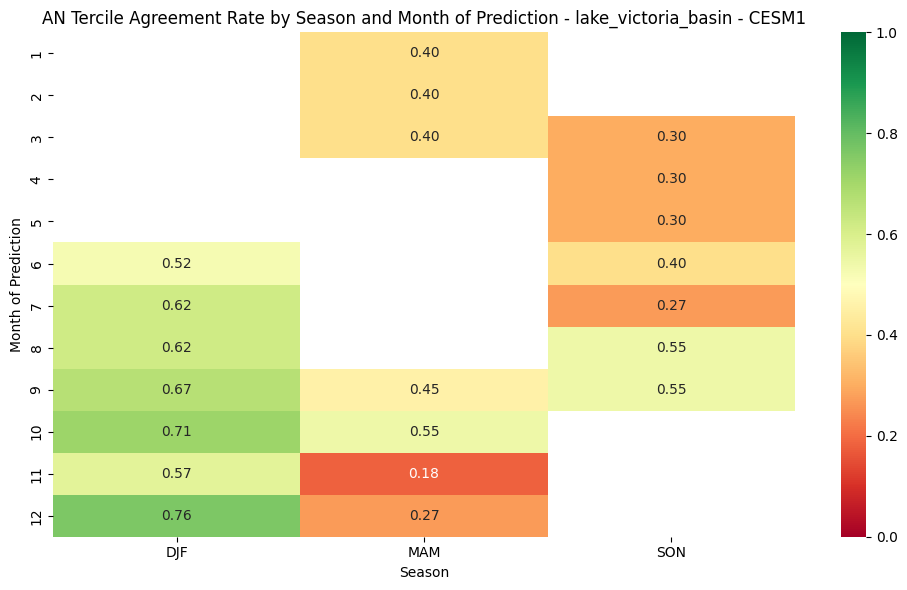

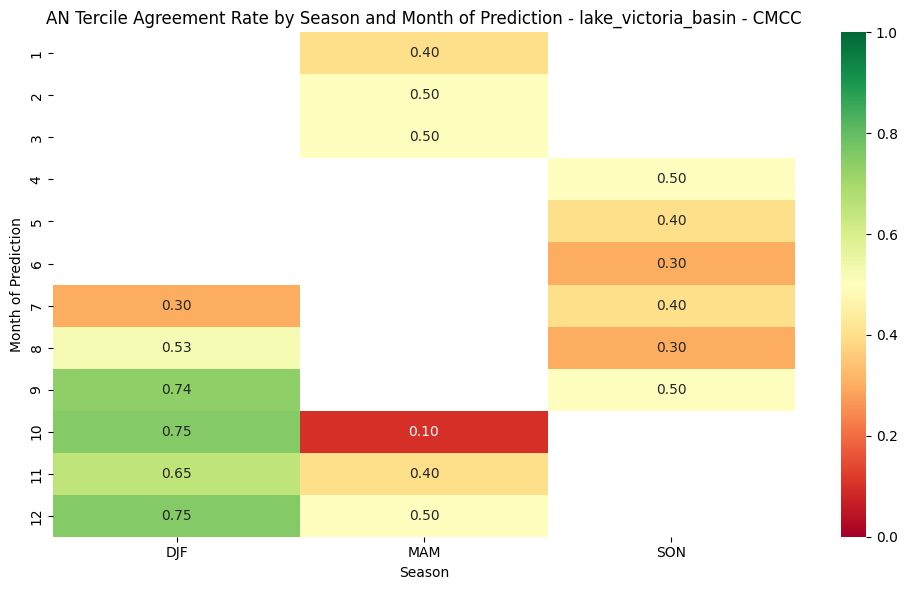

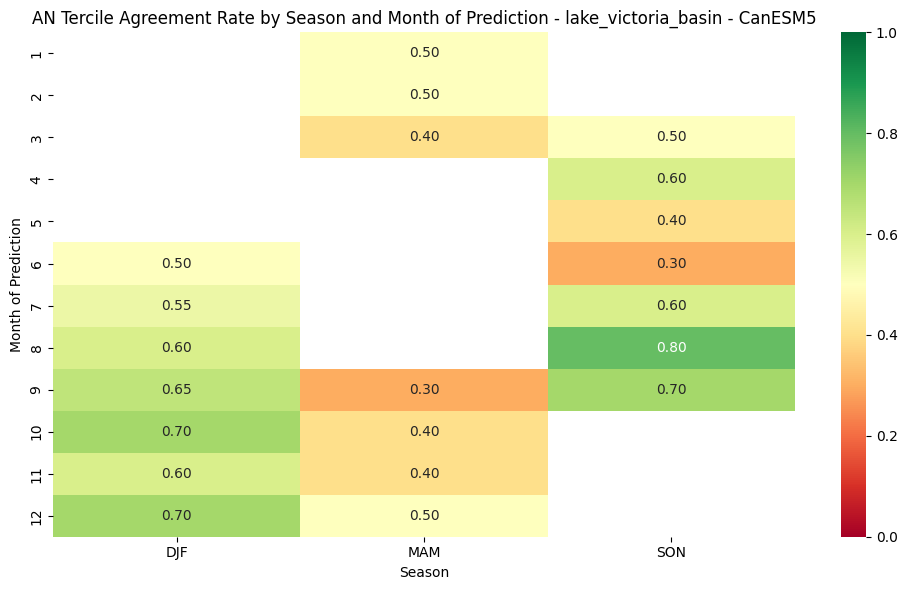

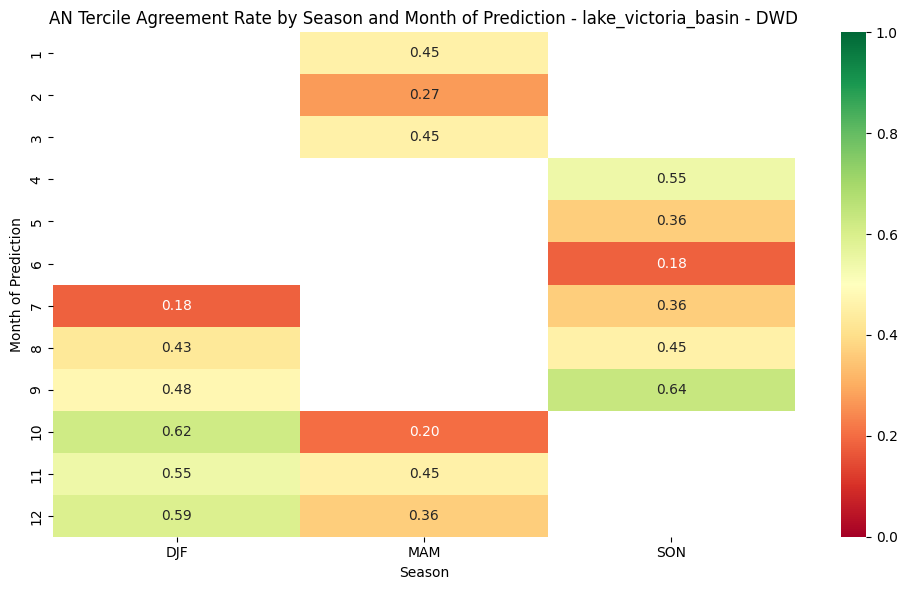

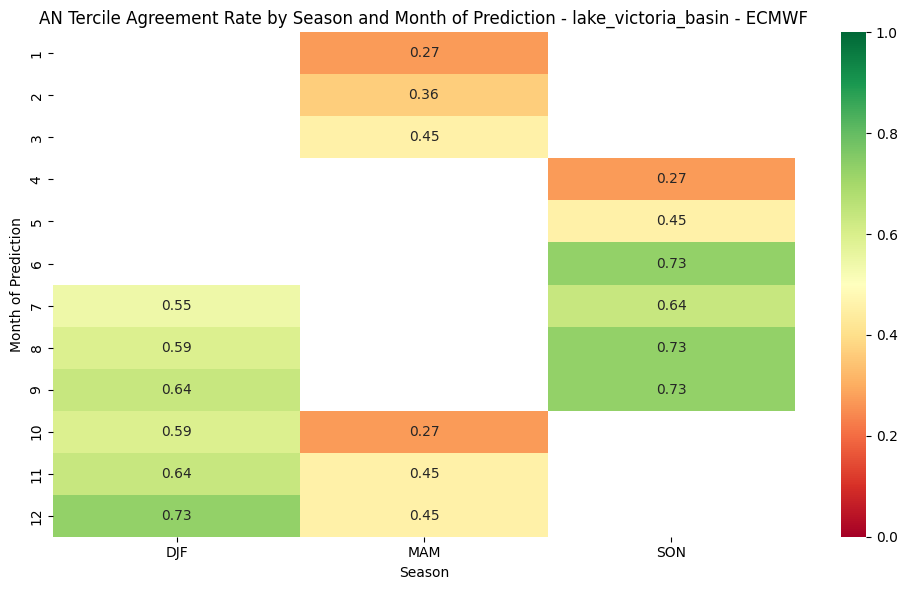

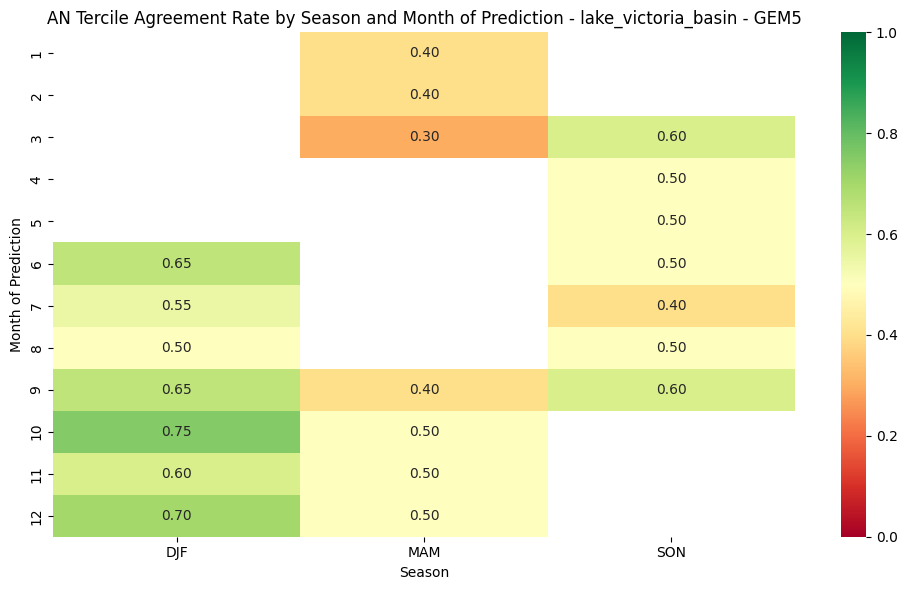

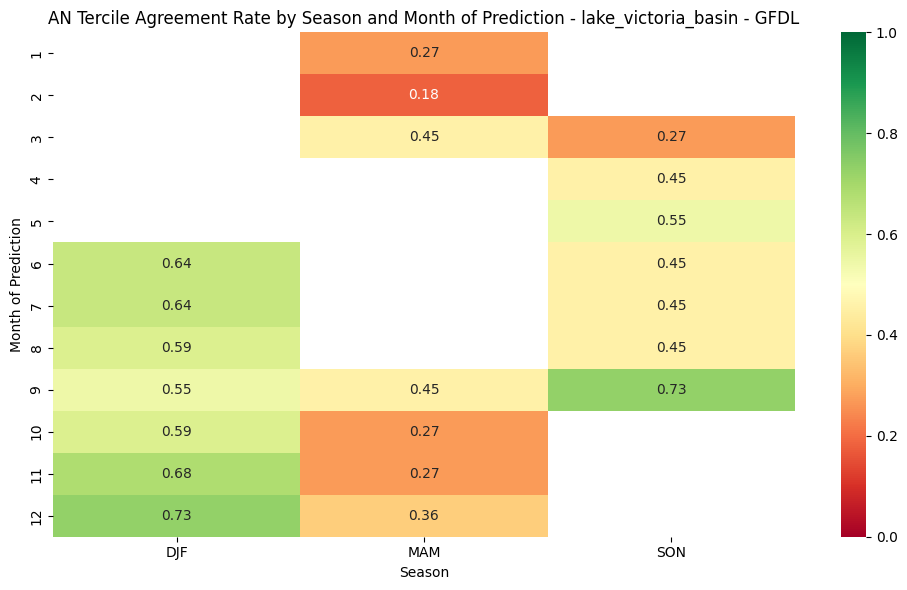

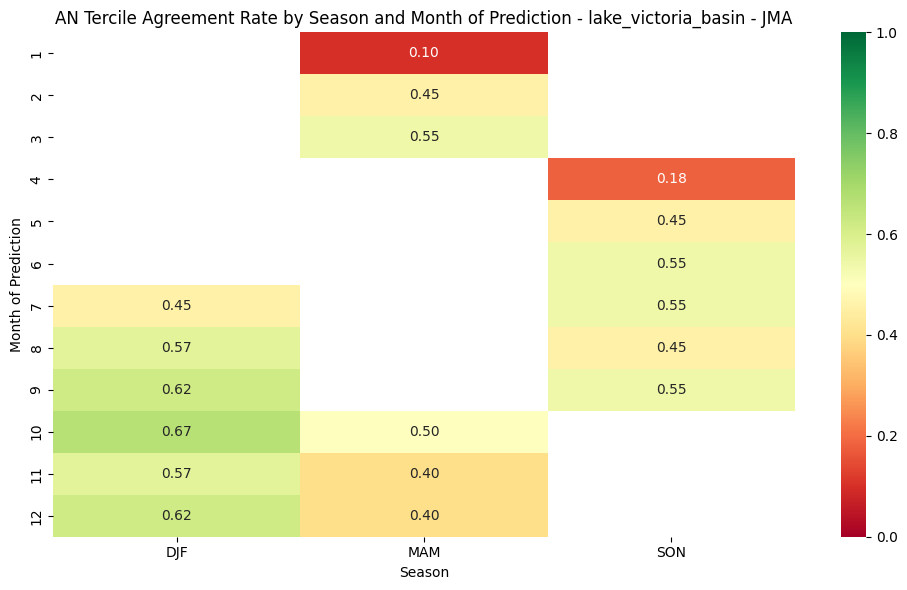

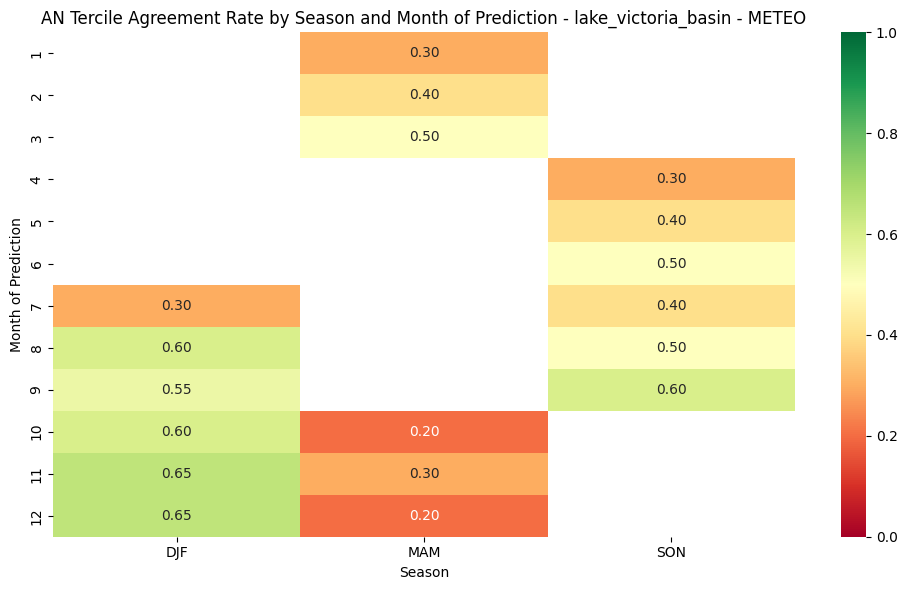

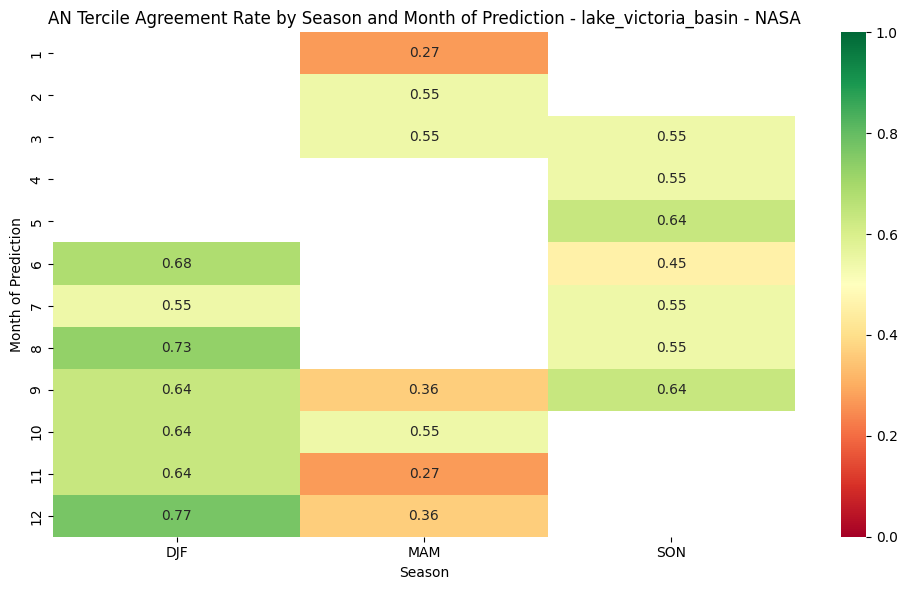

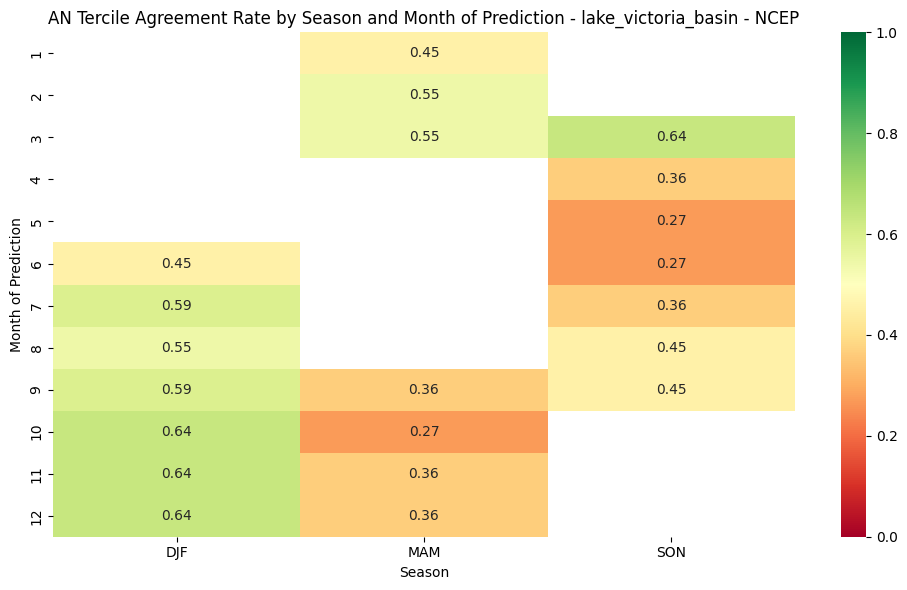

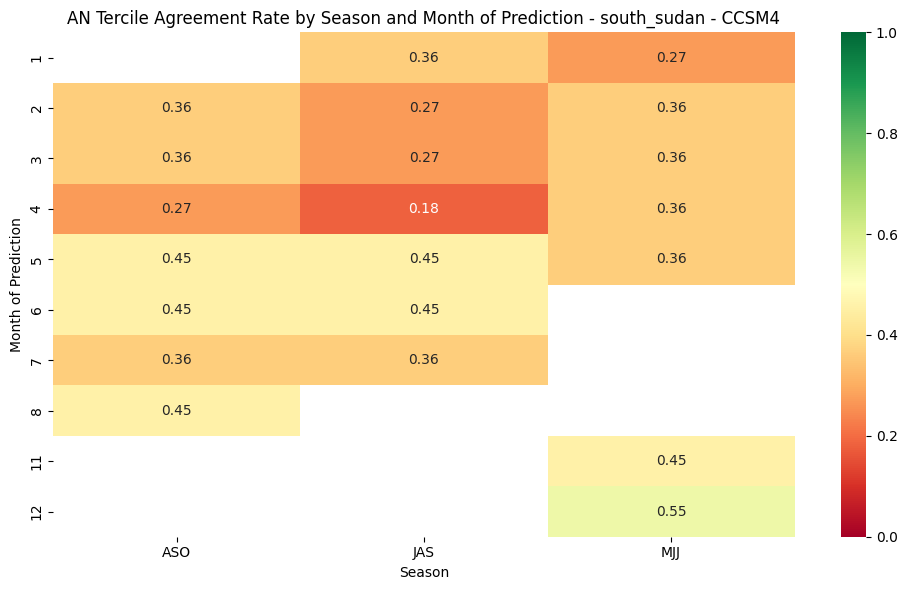

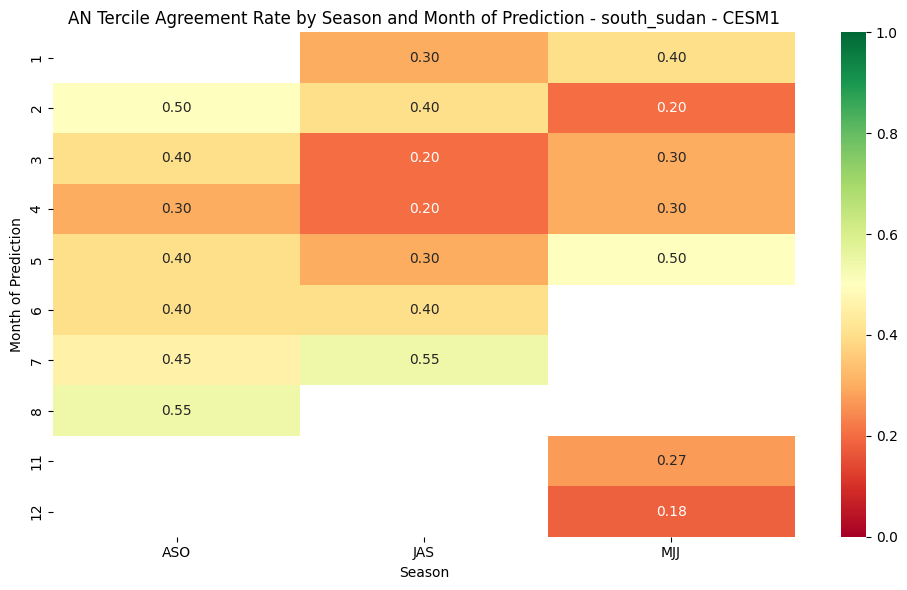

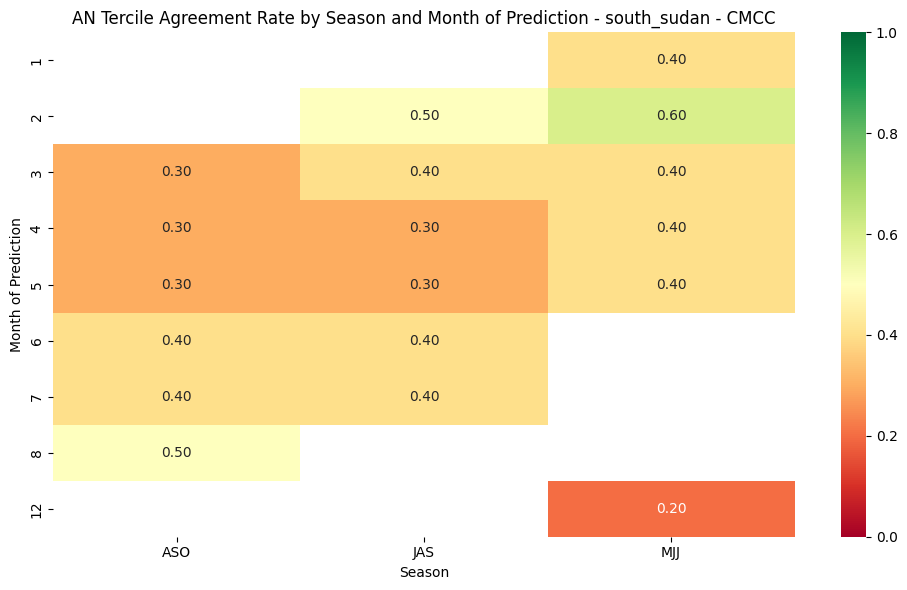

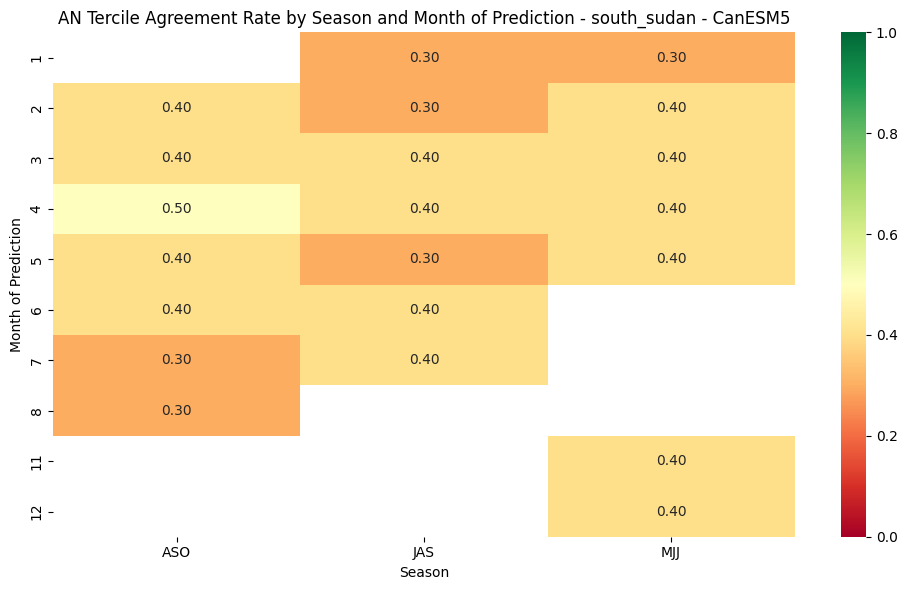

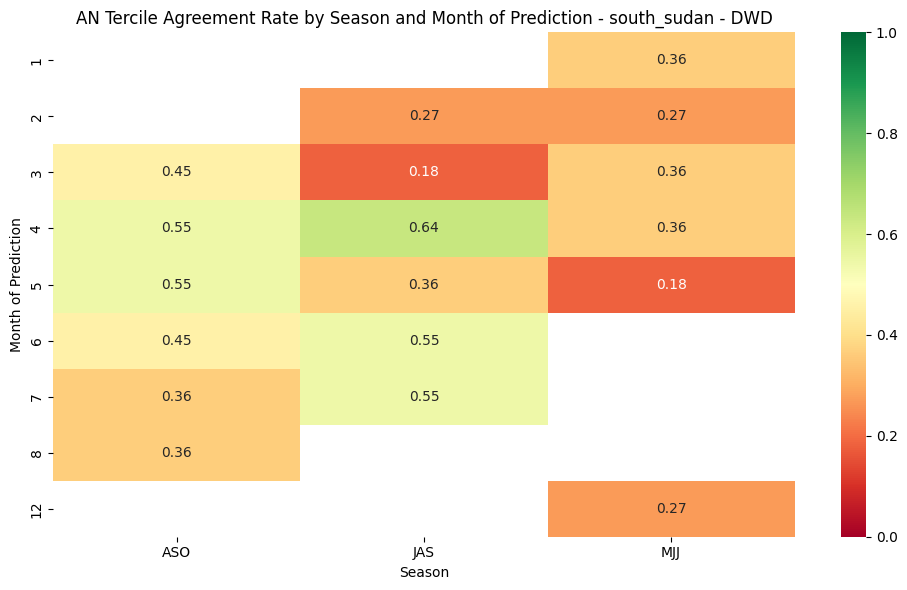

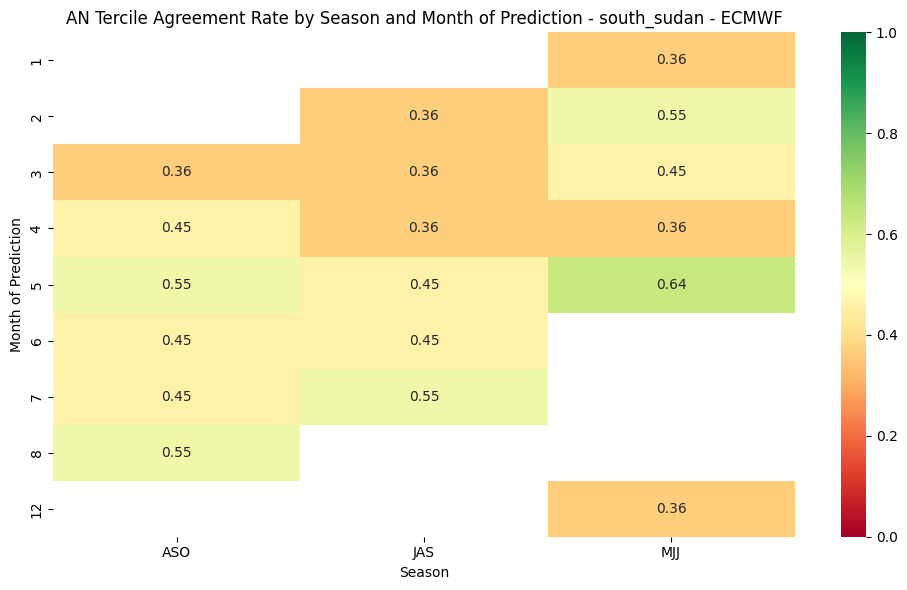

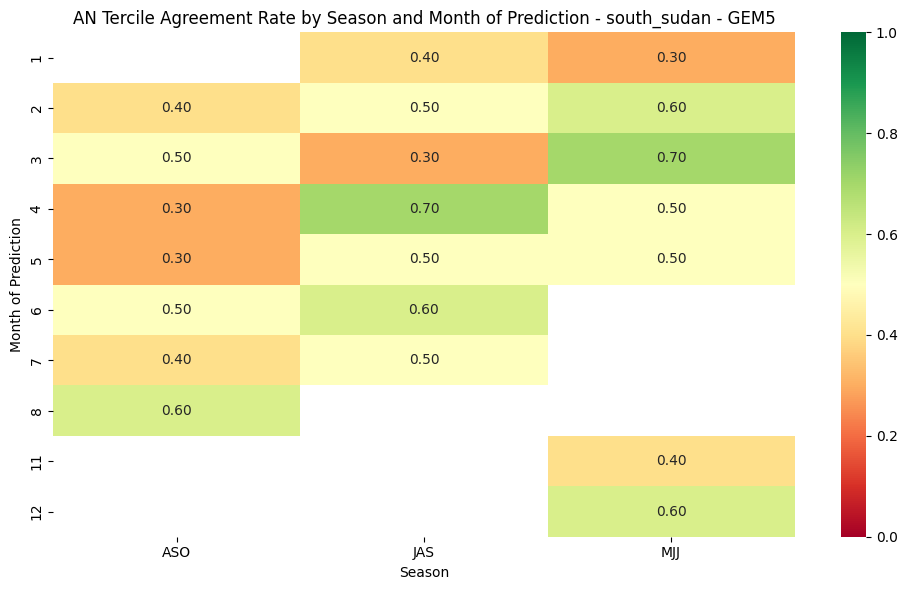

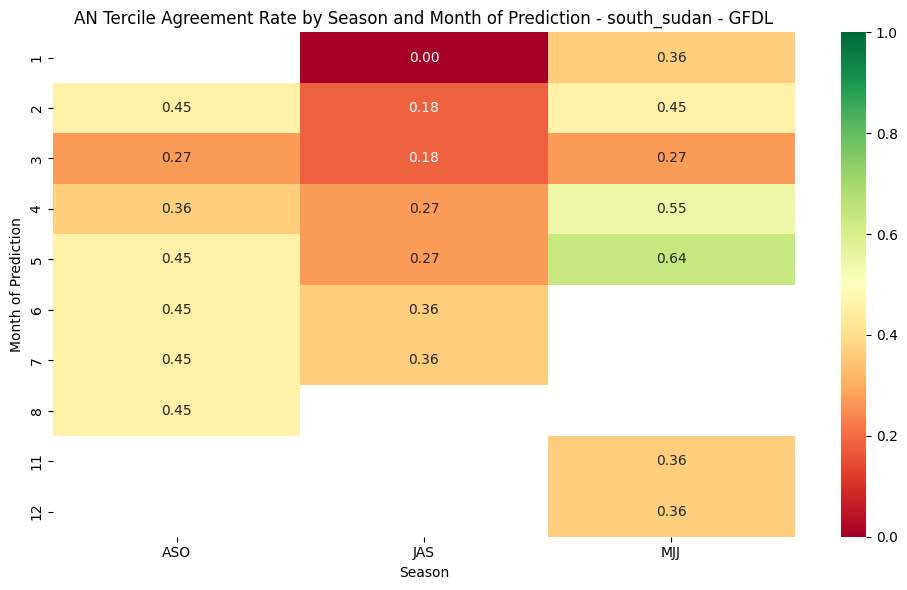

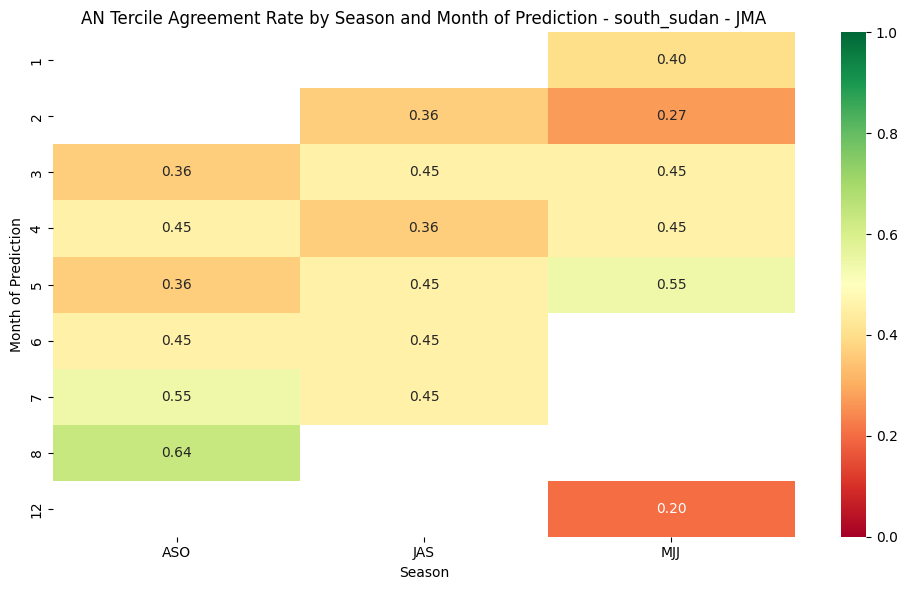

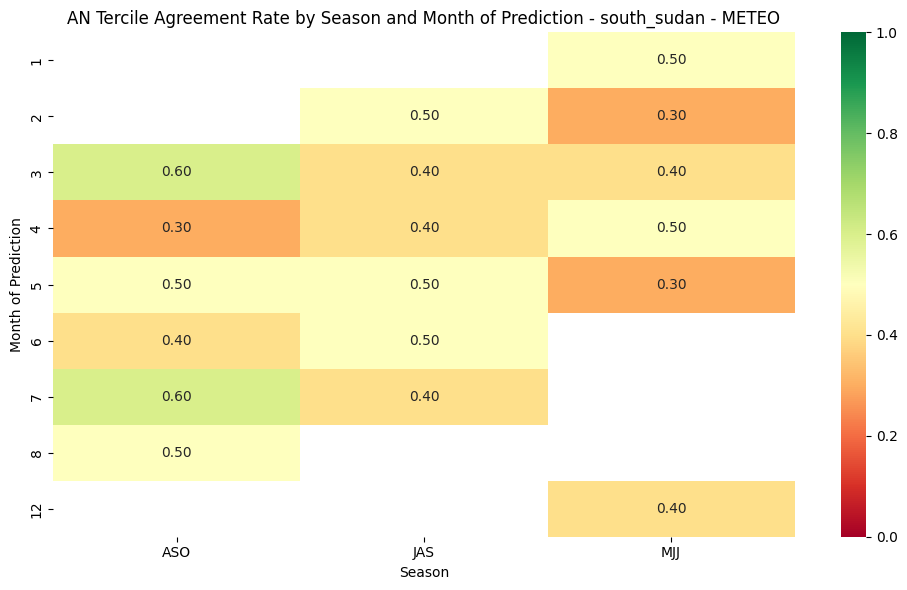

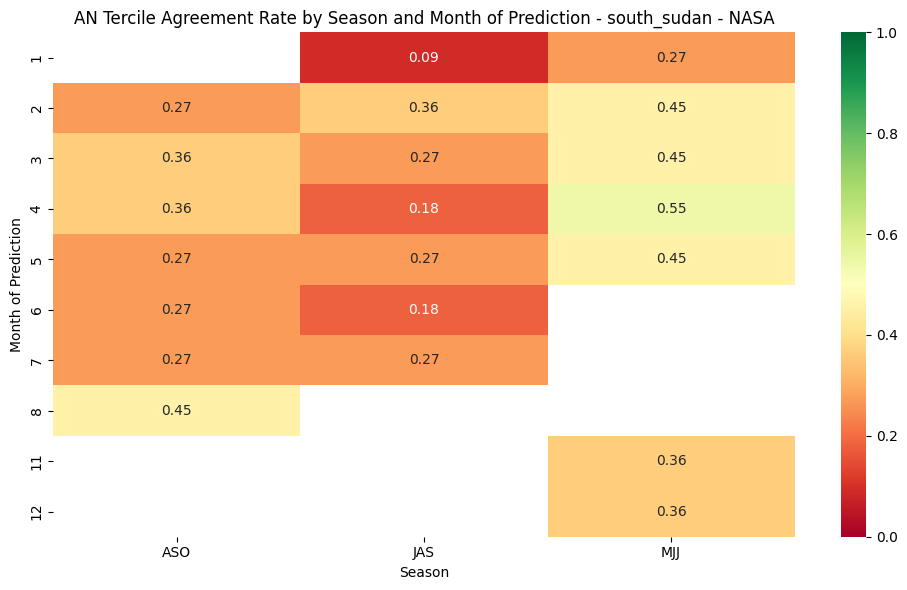

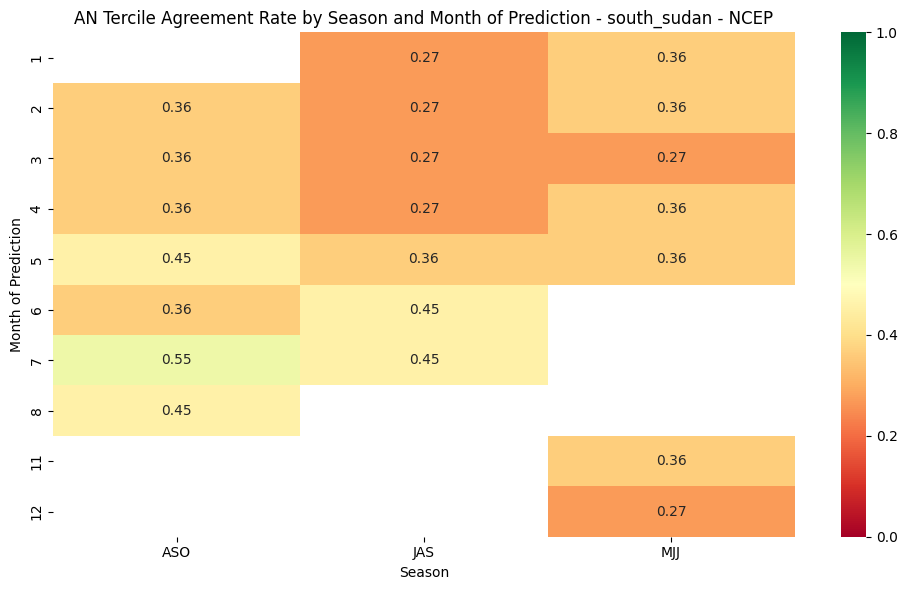

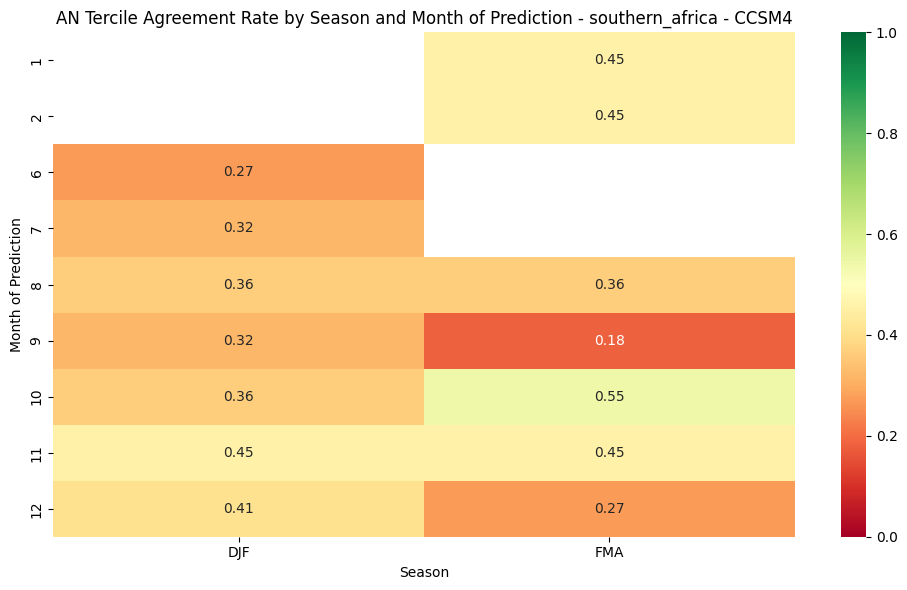

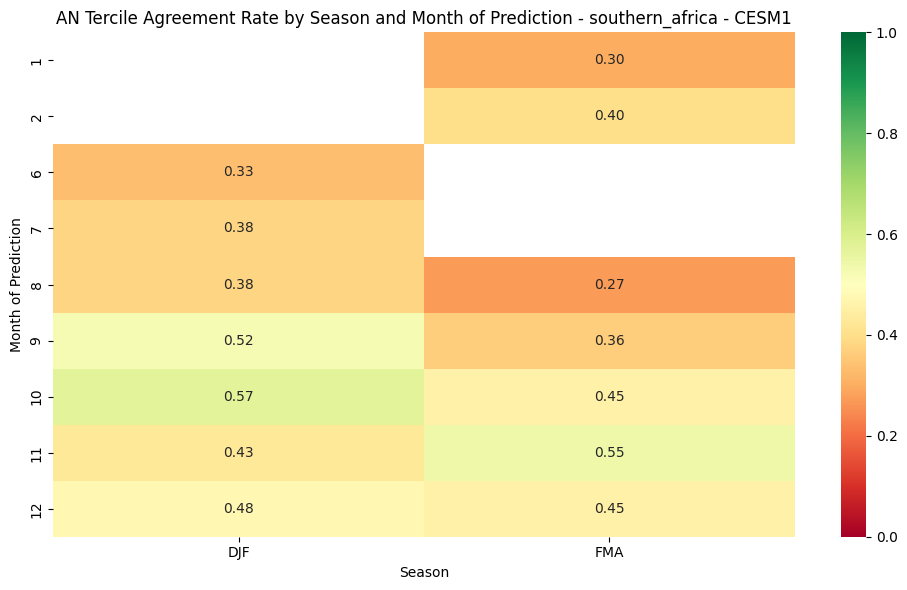

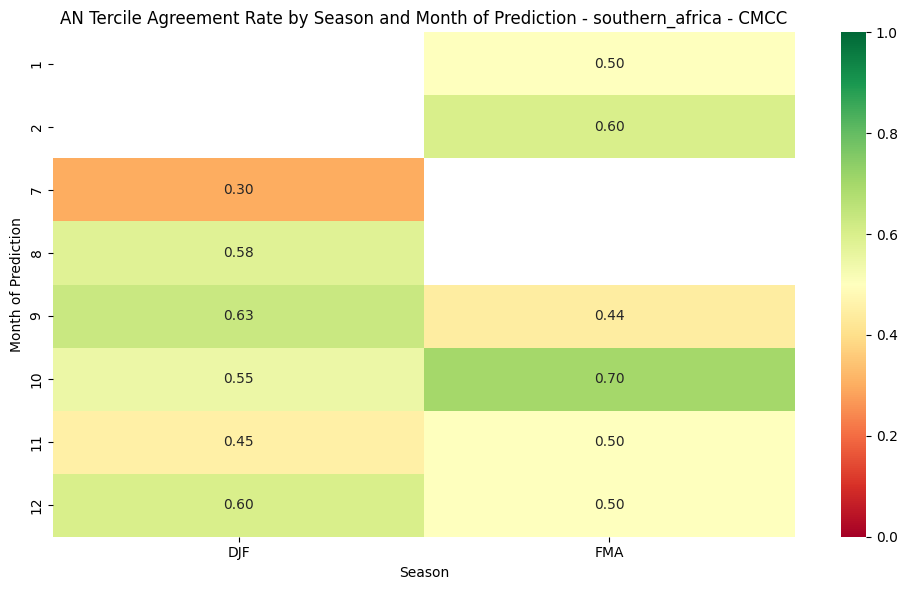

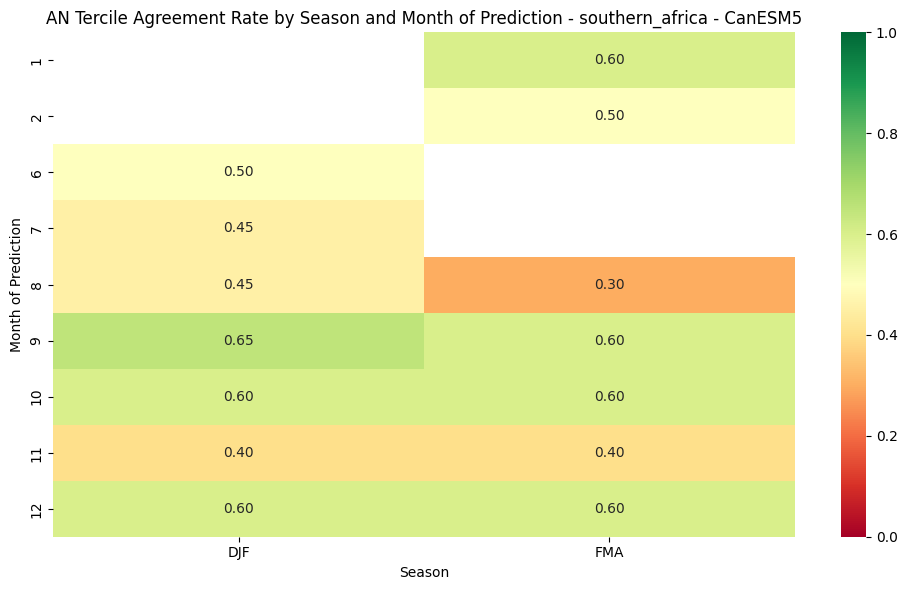

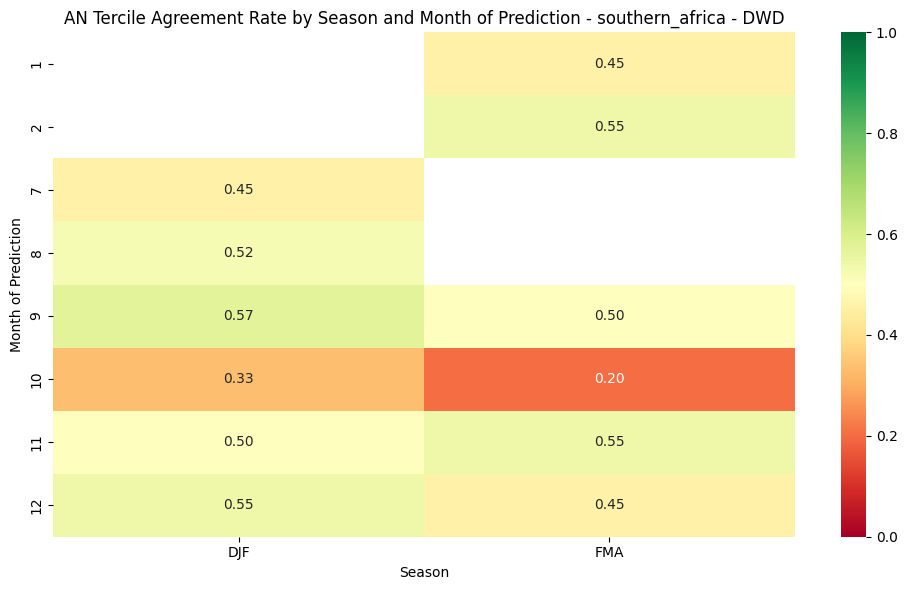

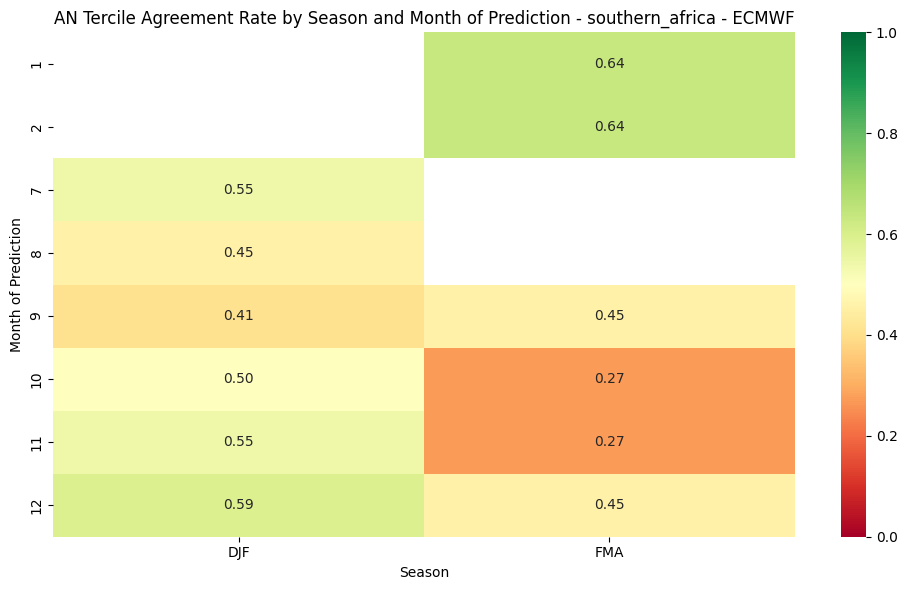

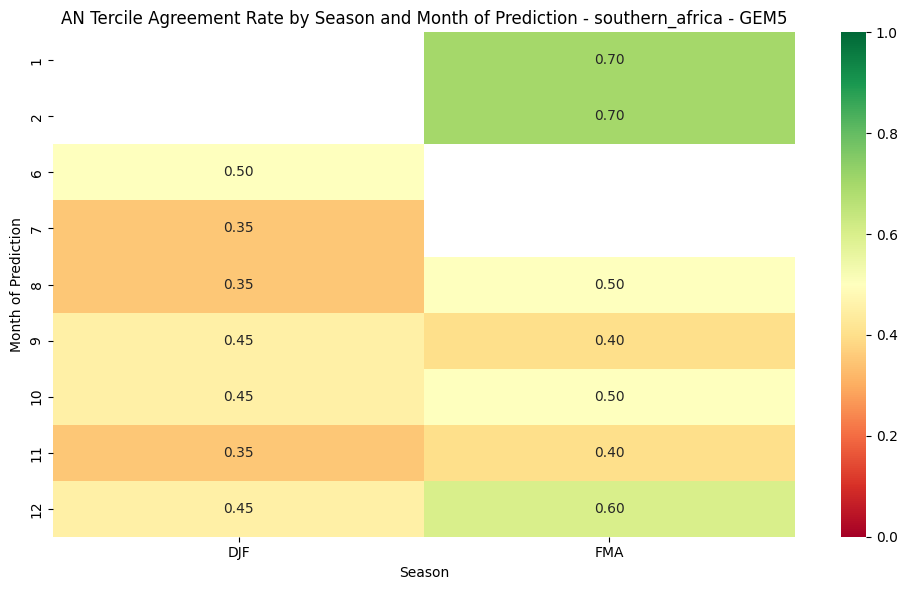

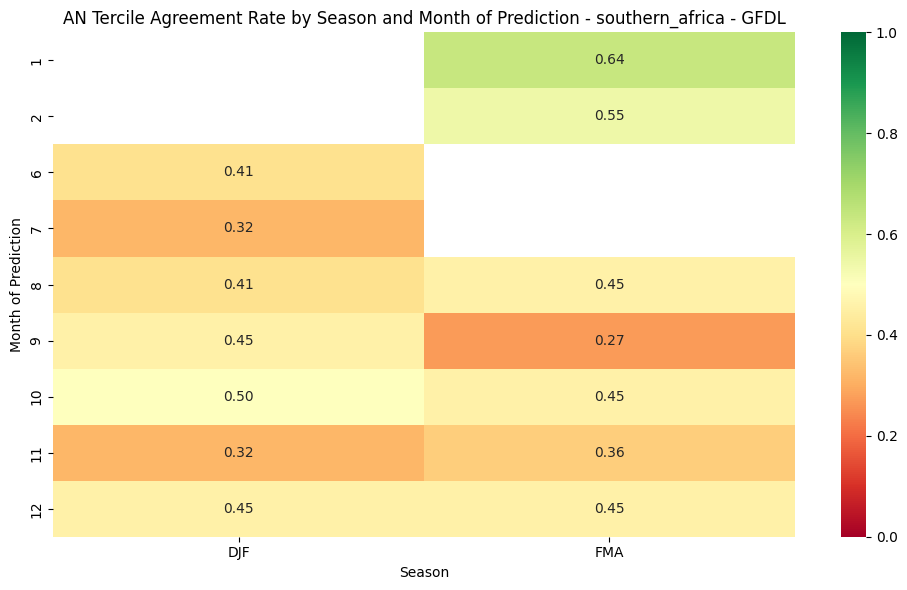

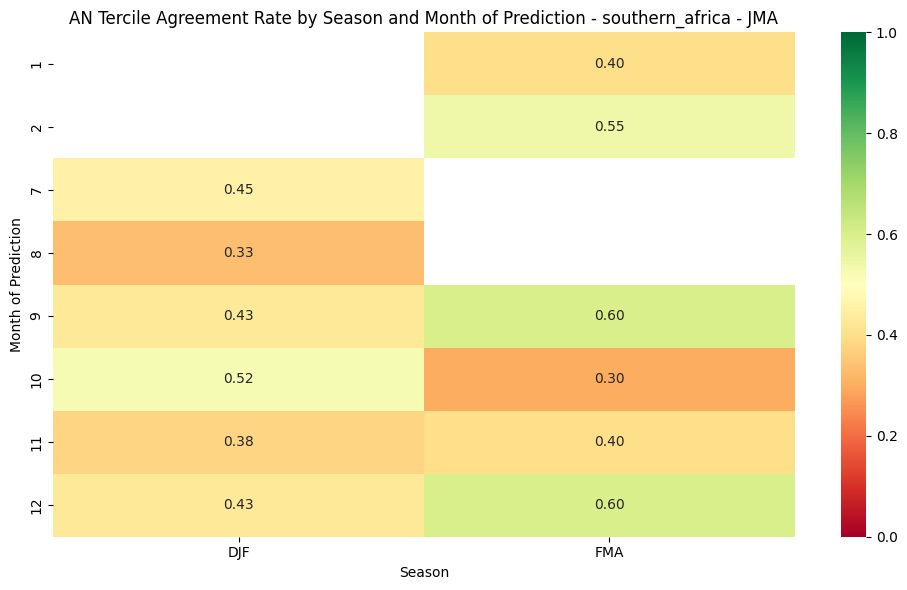

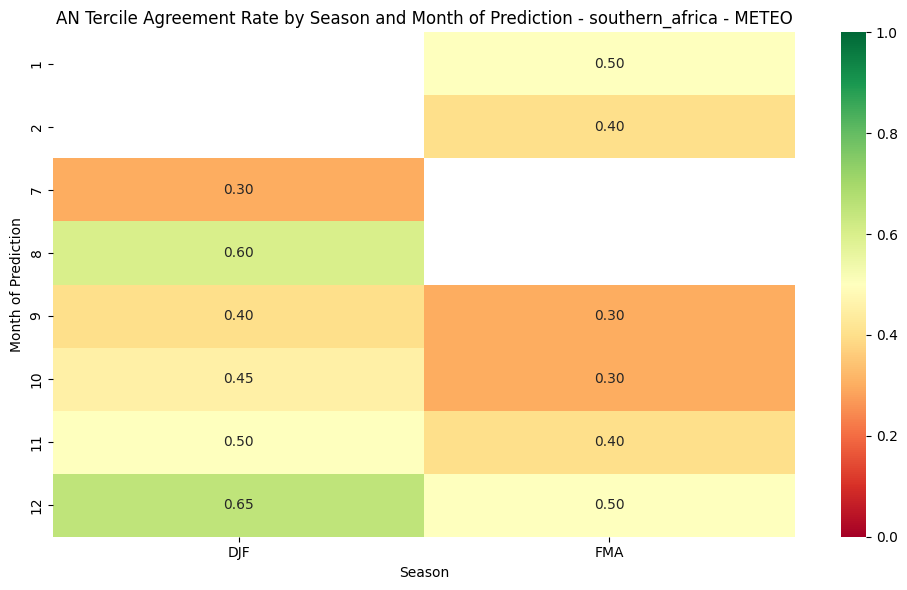

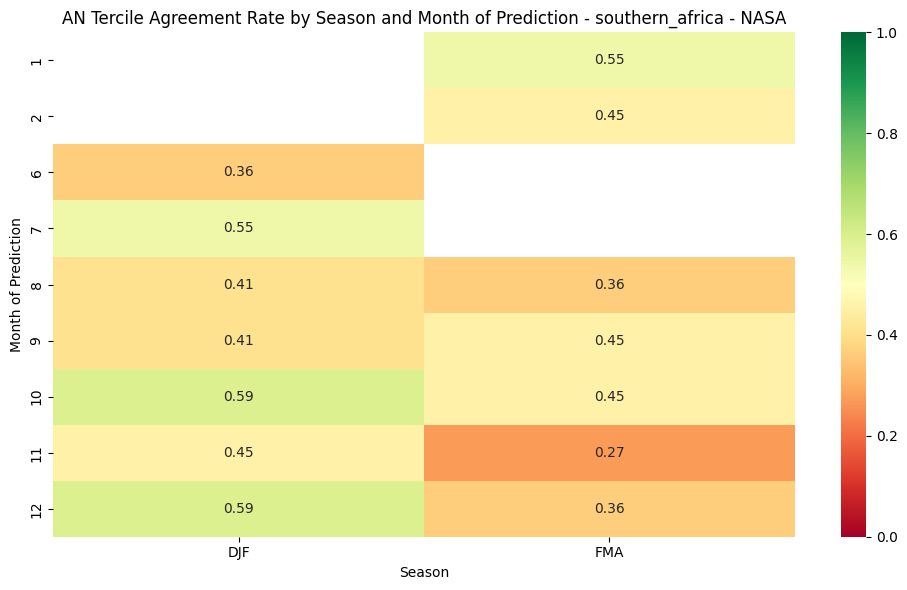

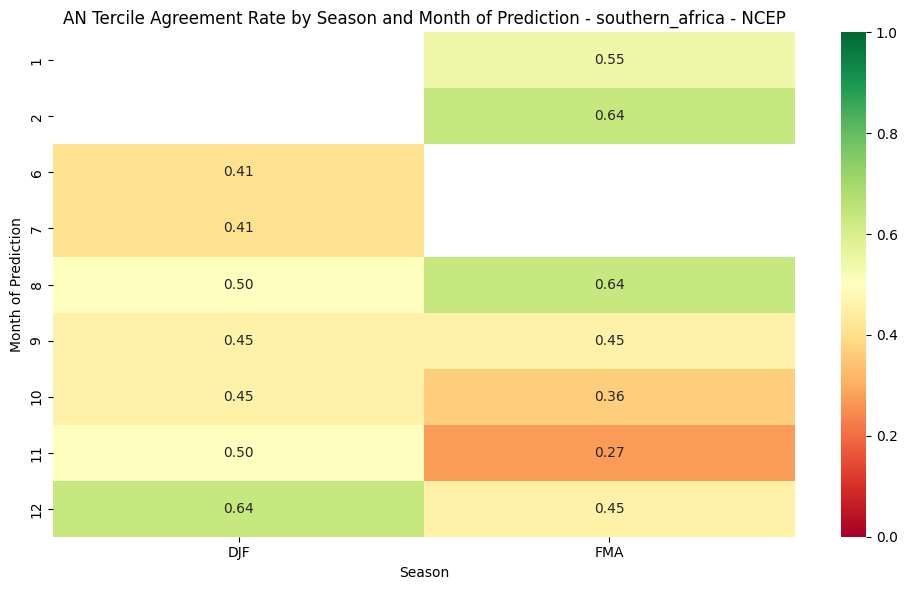

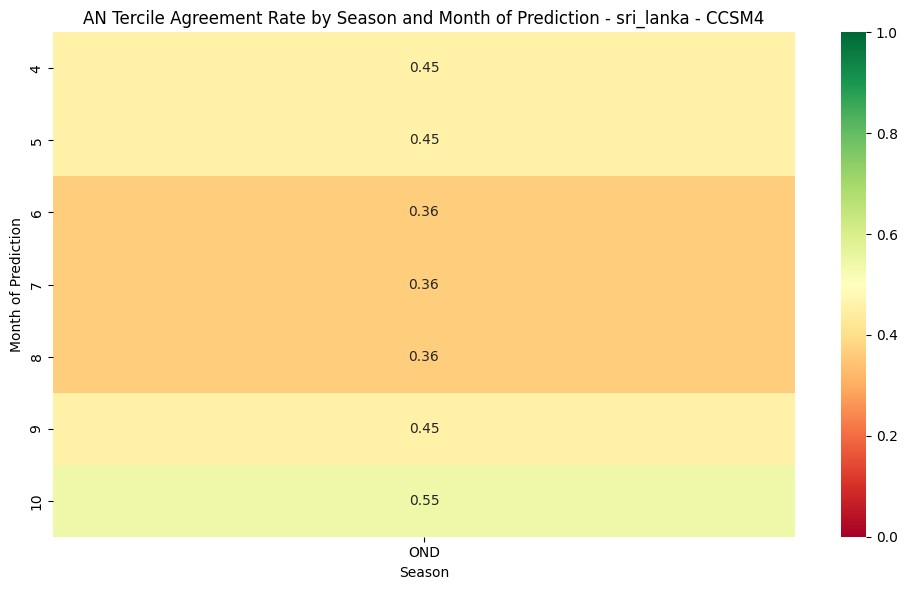

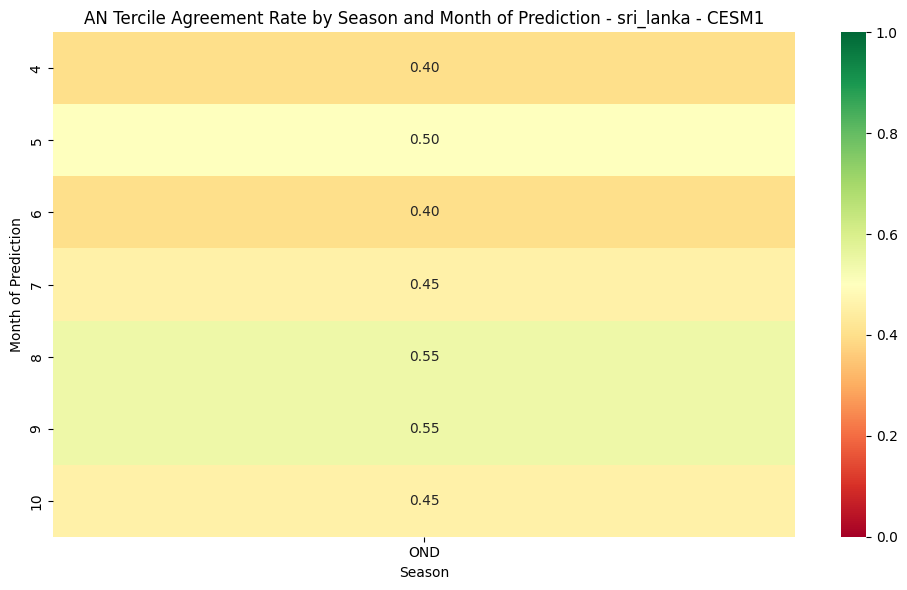

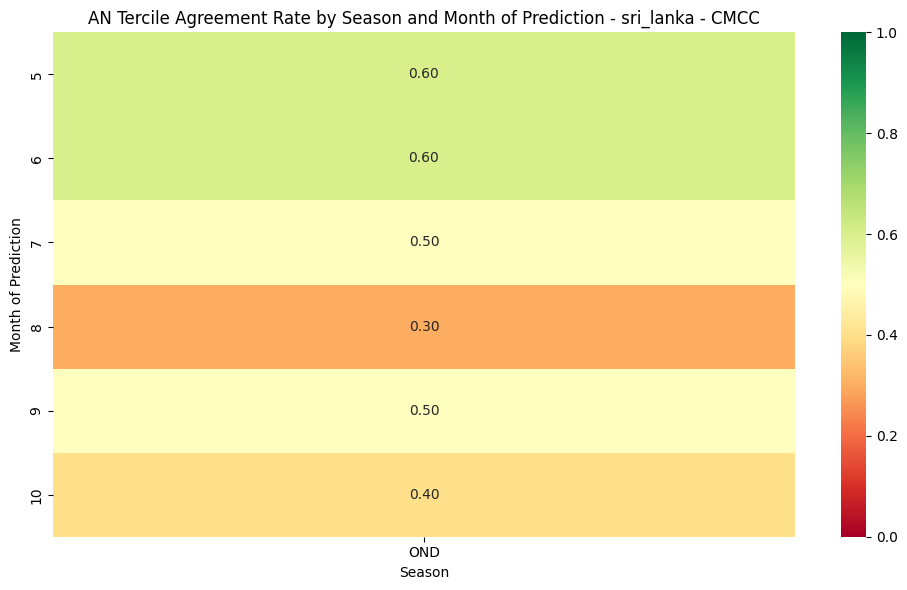

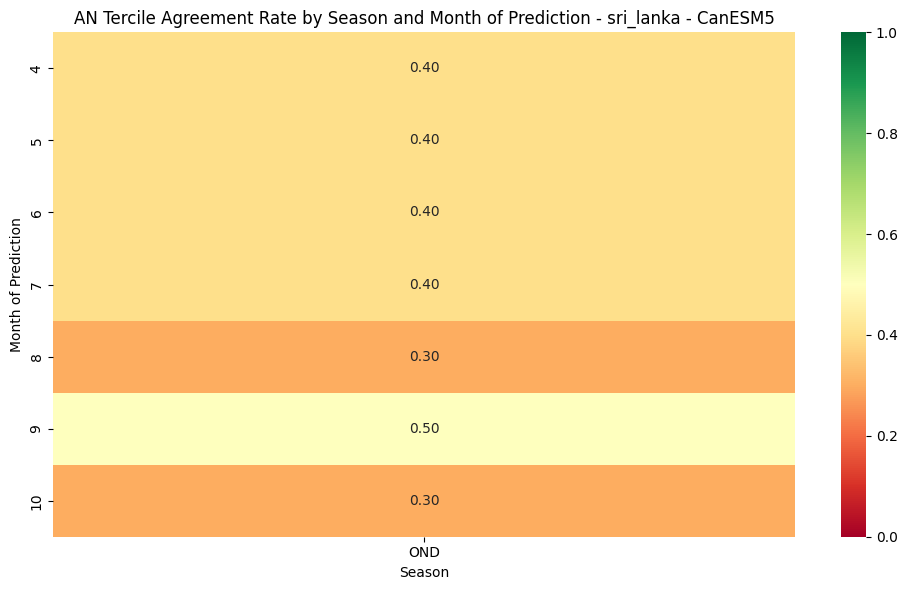

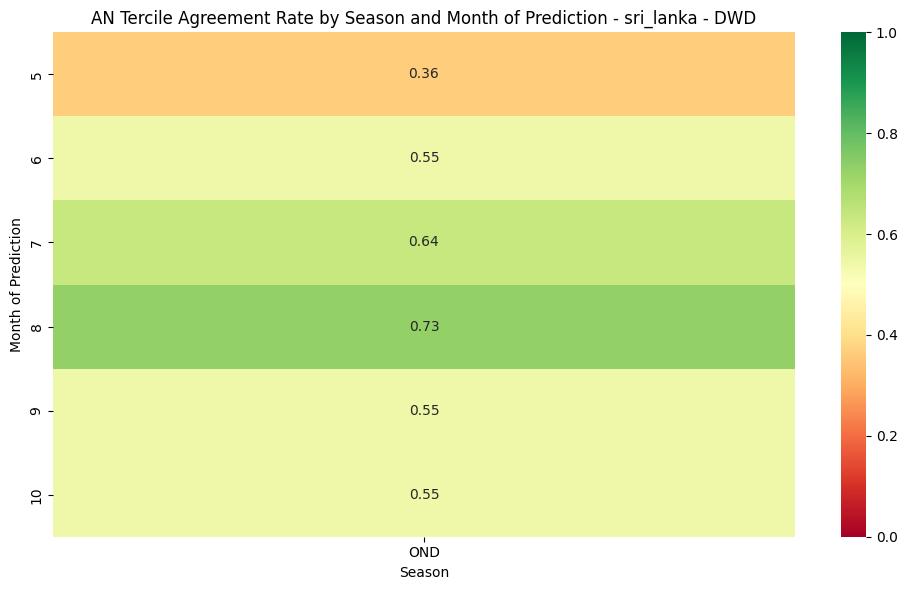

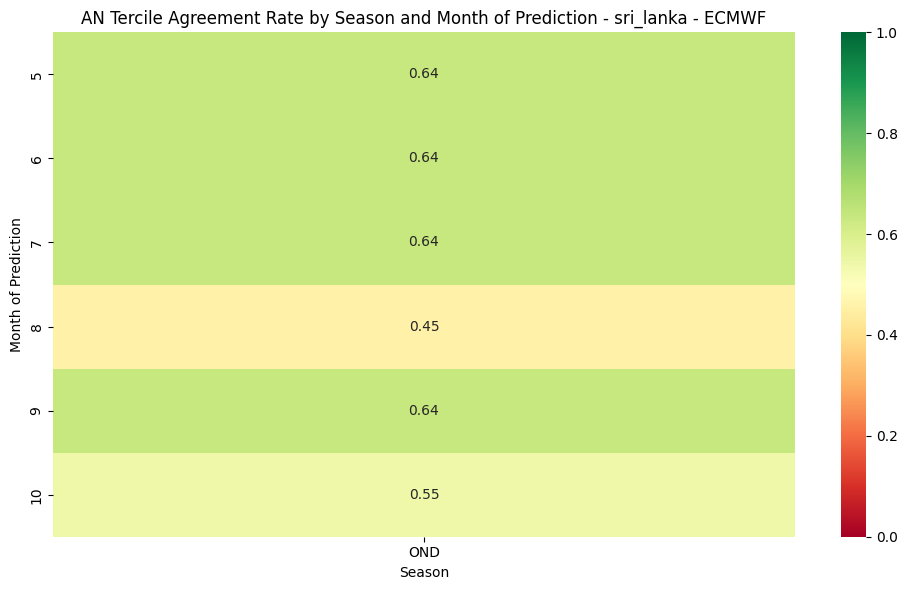

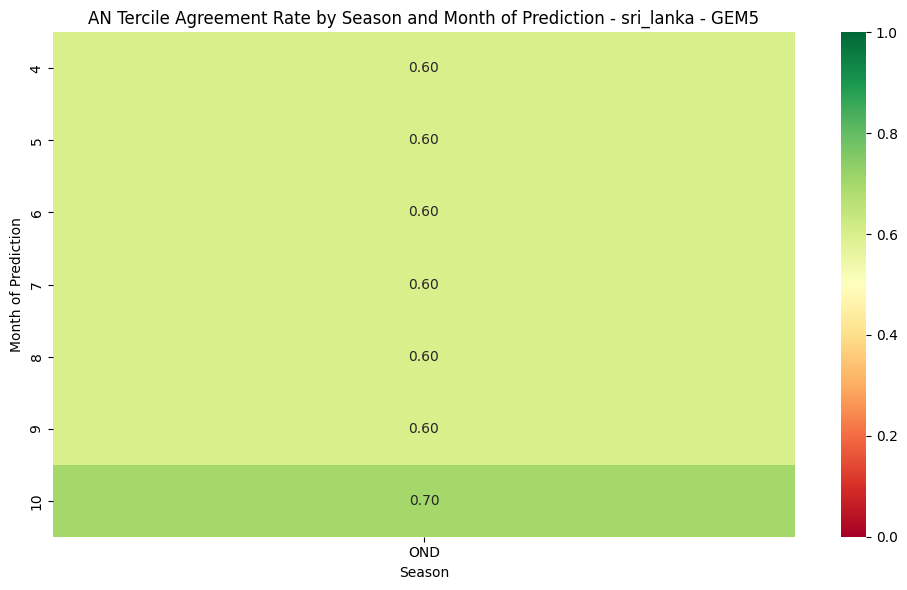

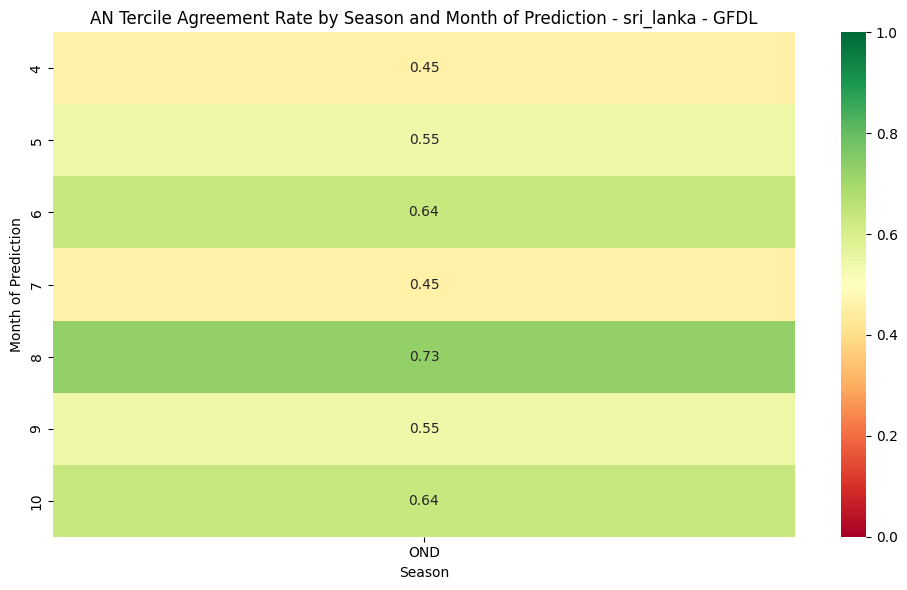

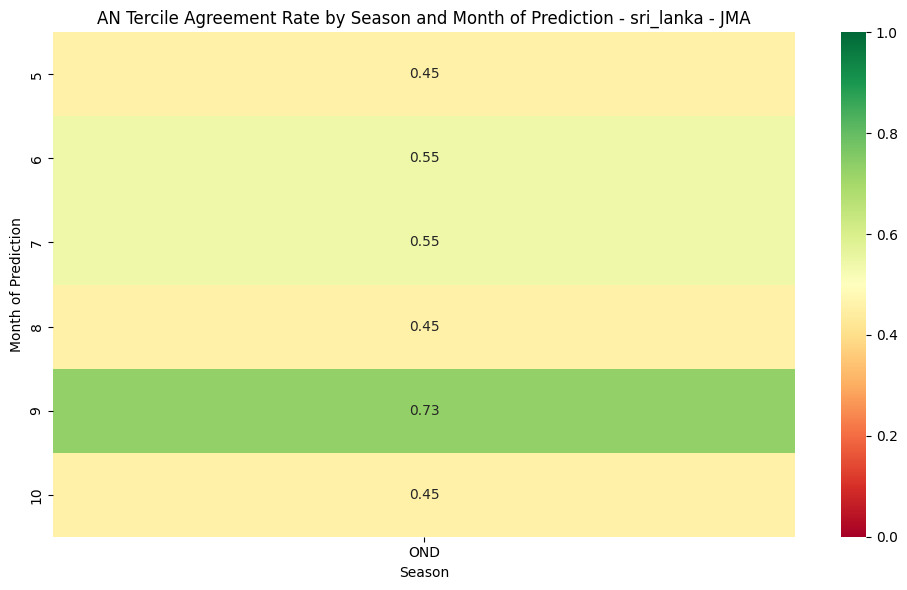

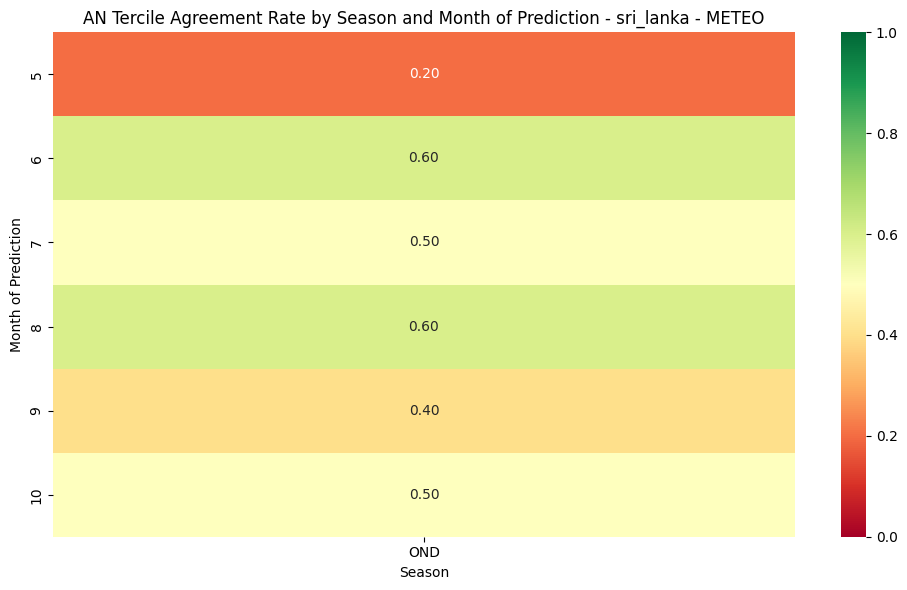

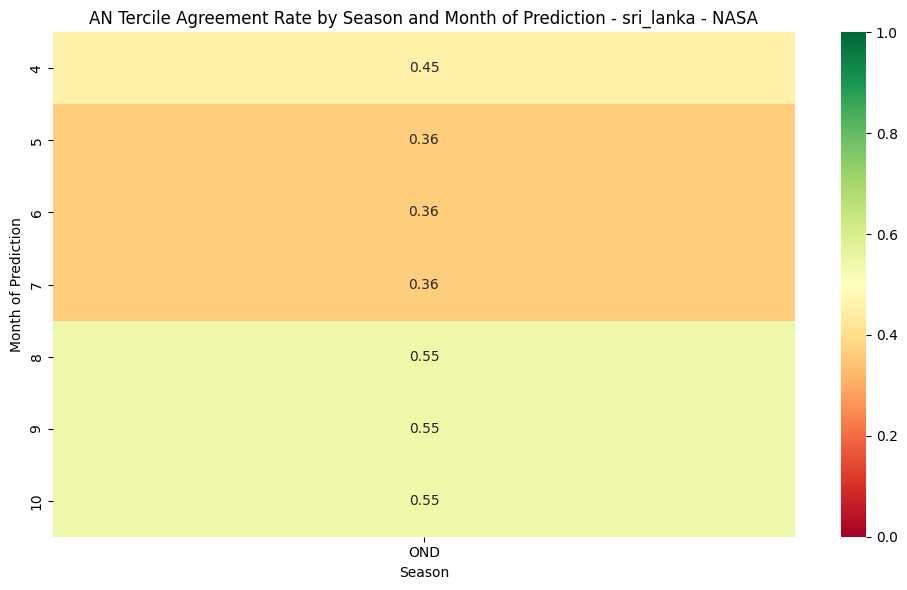

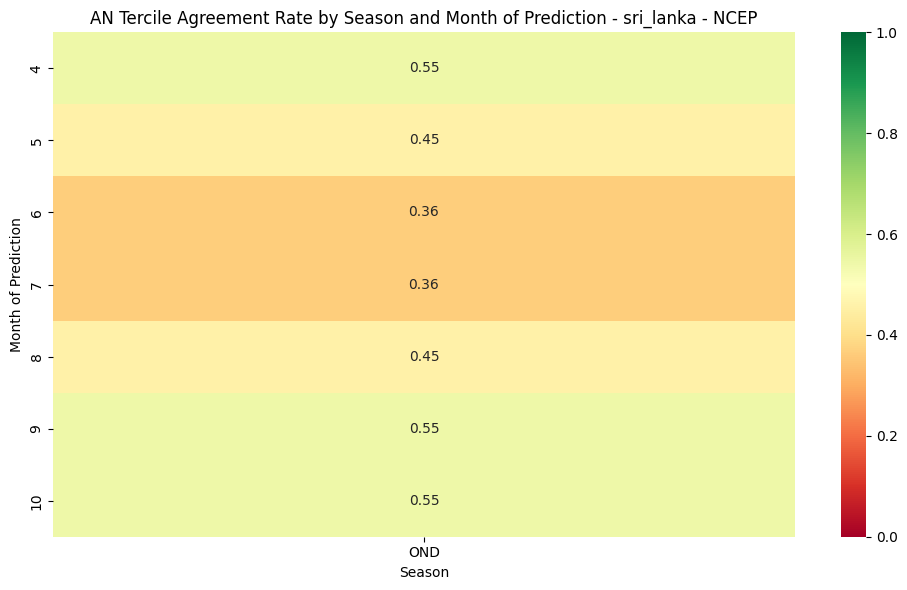

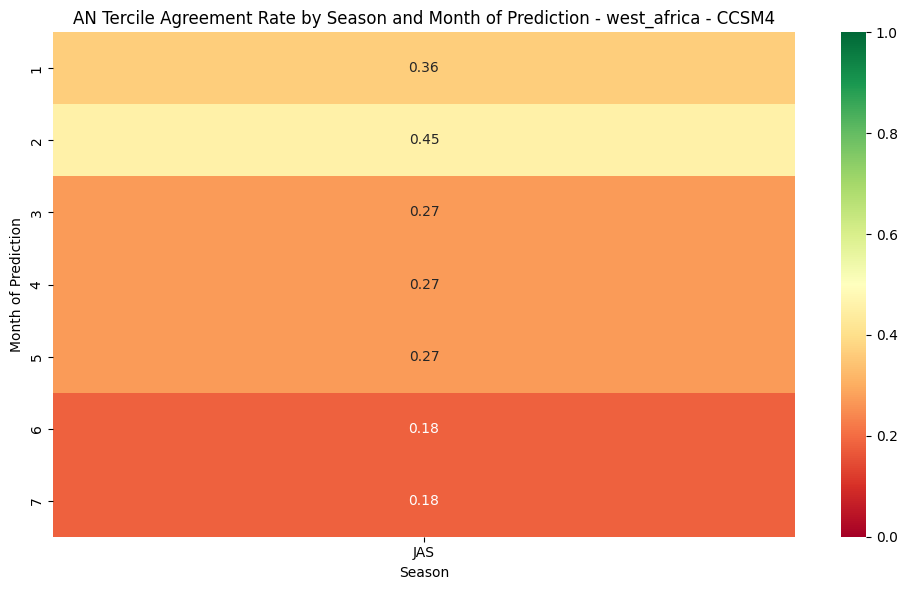

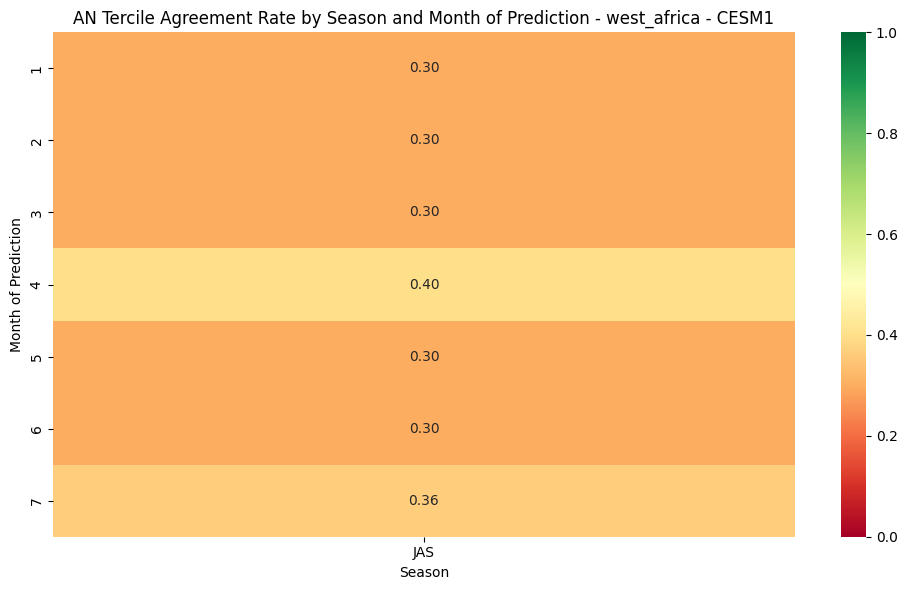

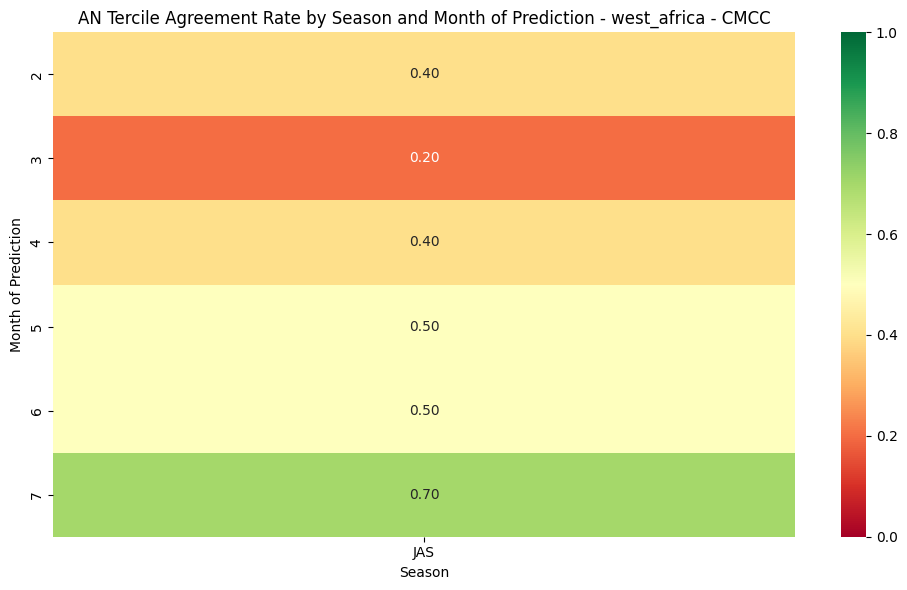

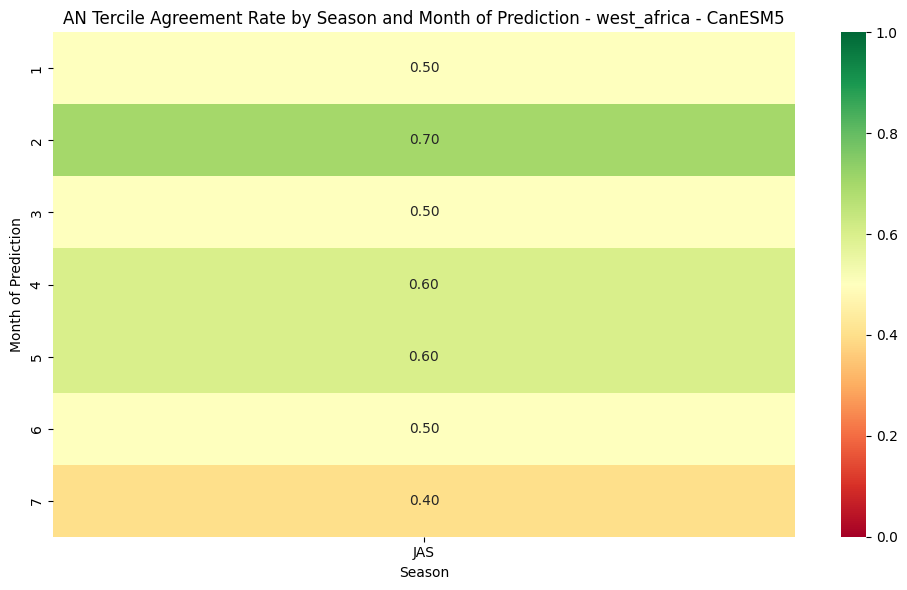

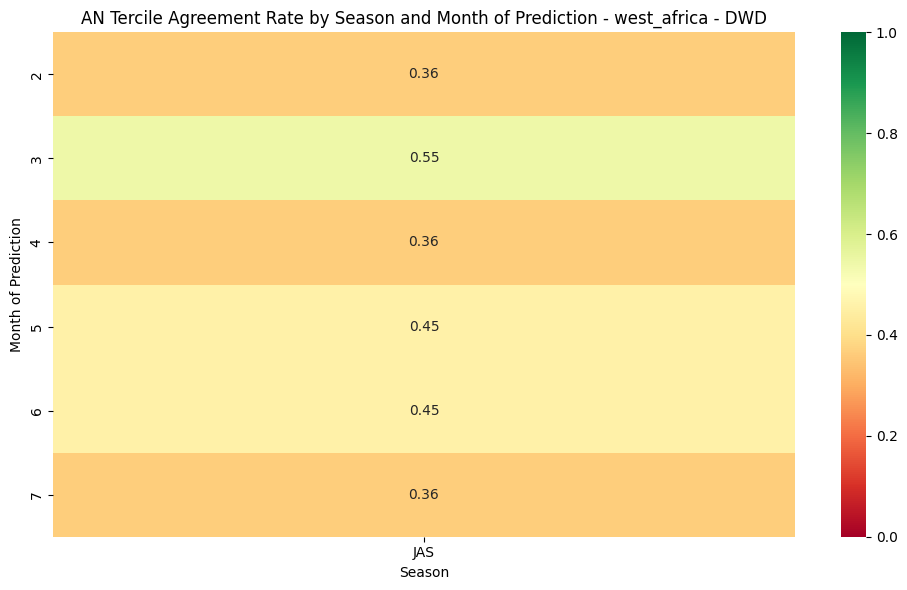

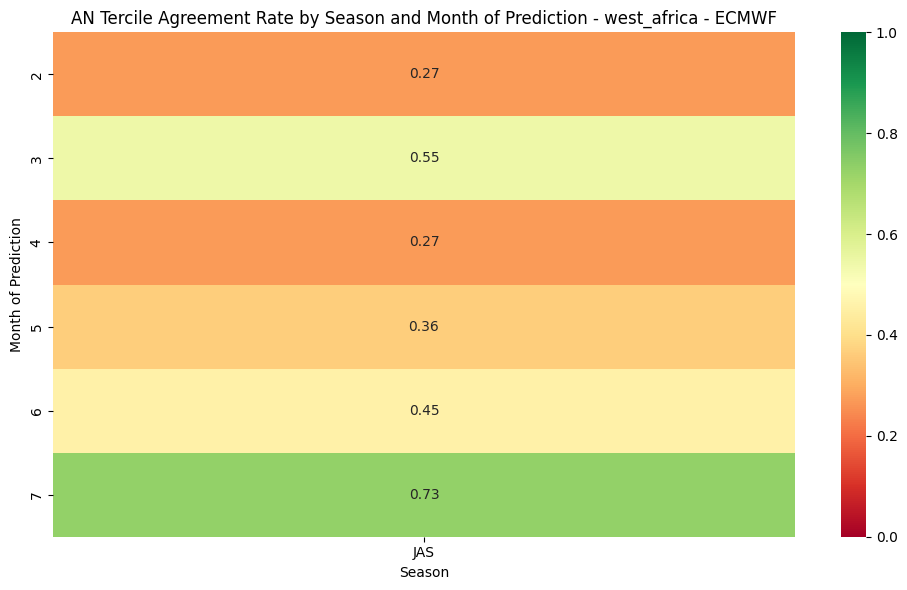

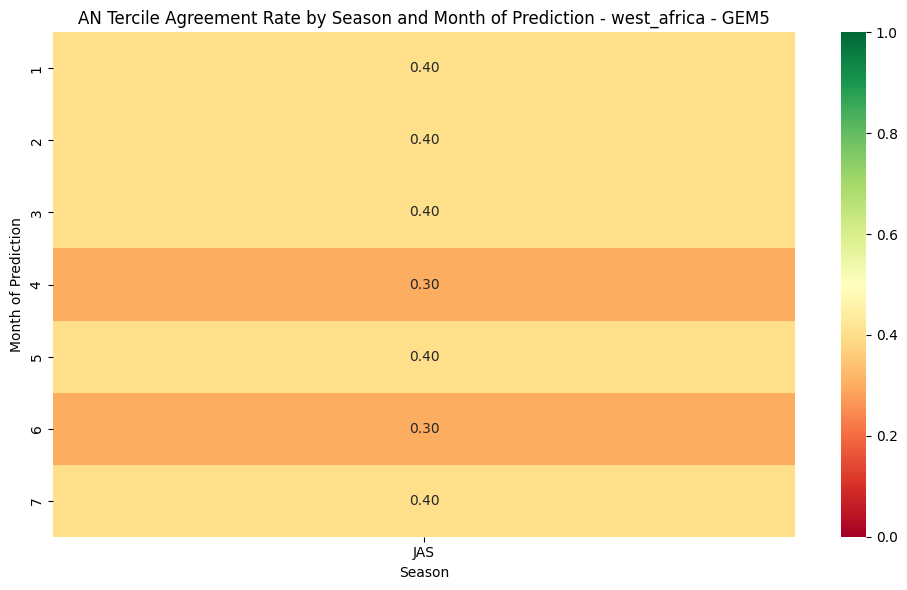

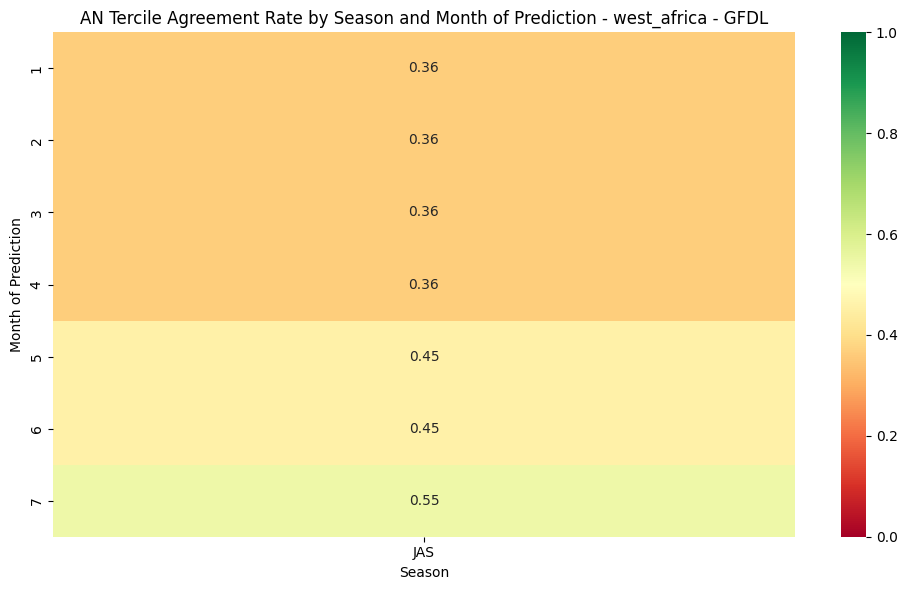

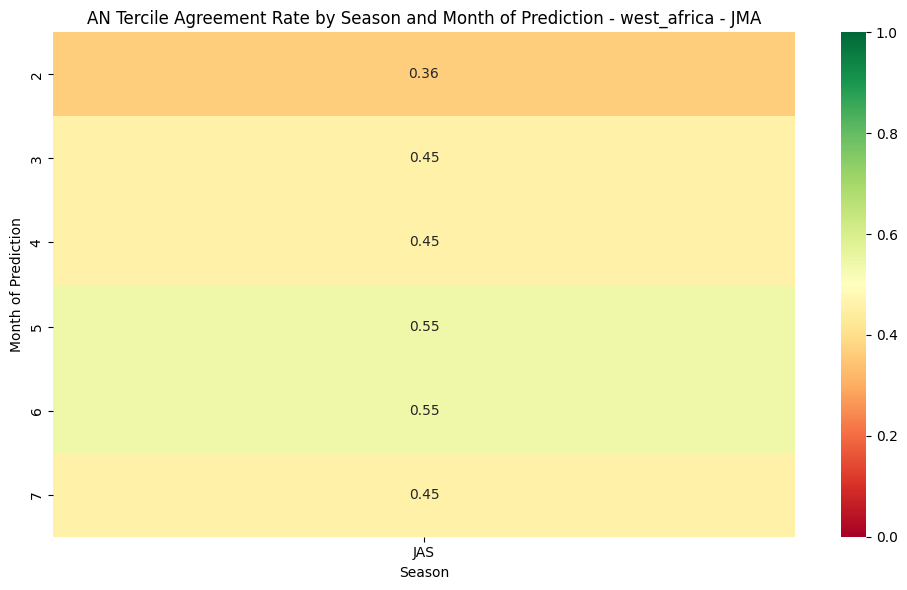

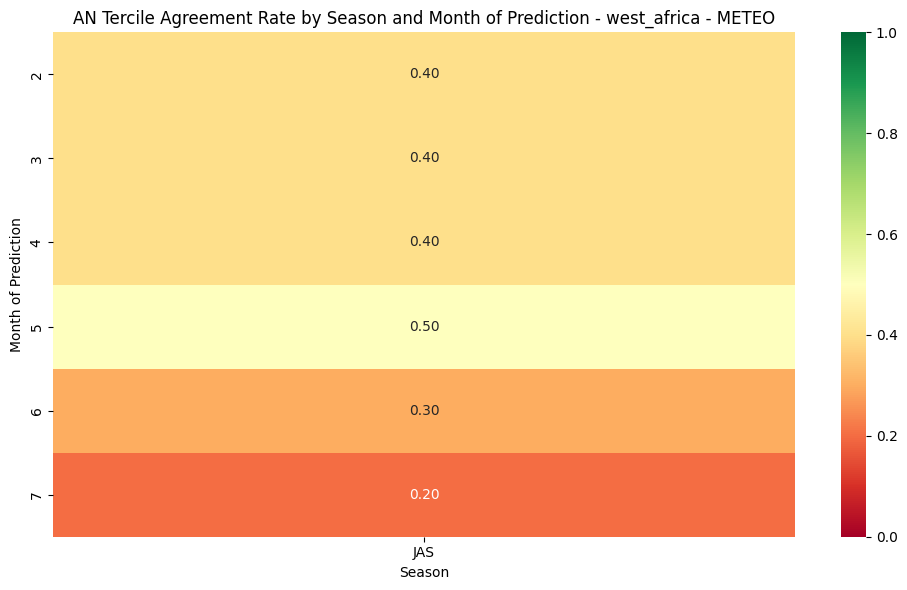

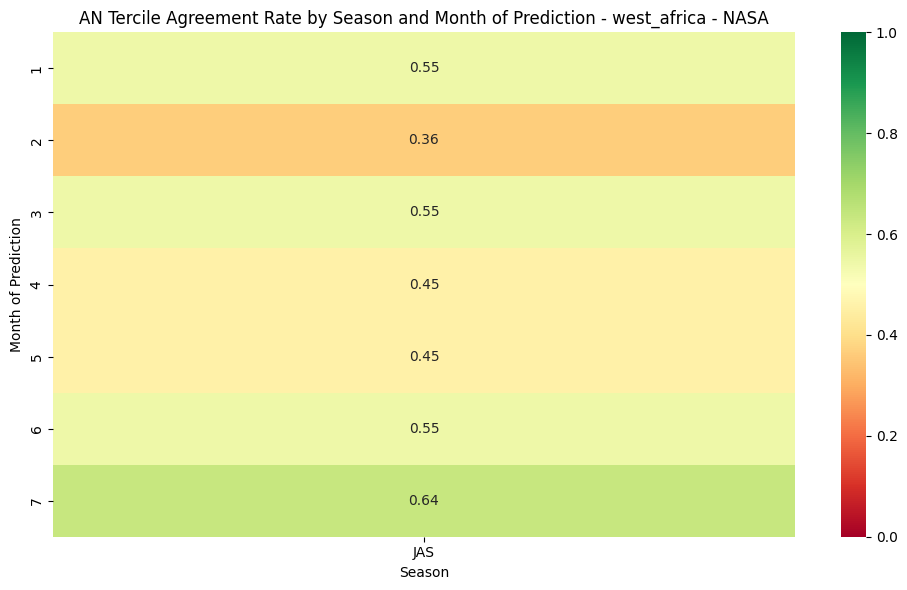

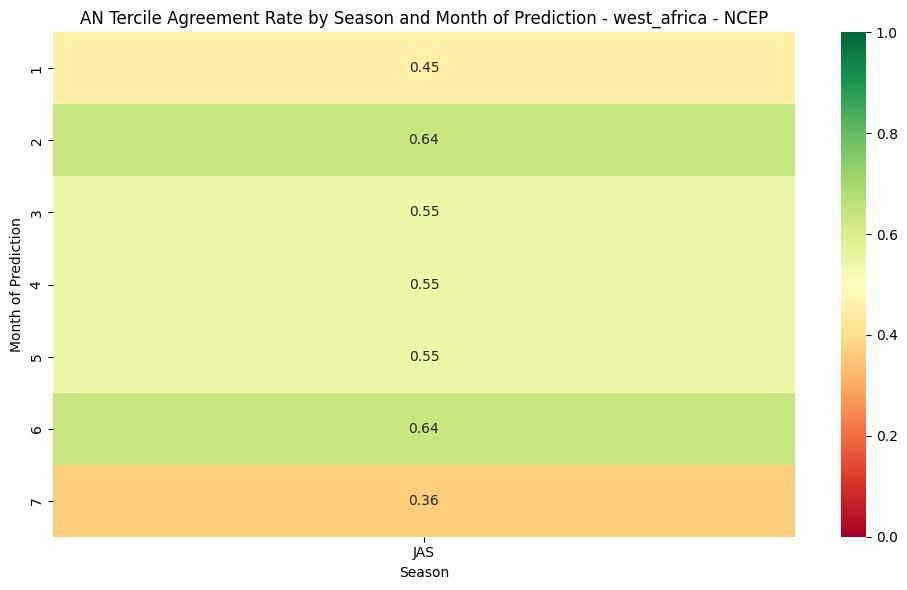

In [164]:
def plot_individual_heatmaps(df):
    # Aggregate duplicates by taking the mean
    df_agg = df.groupby(['month_of_prediction', 'season', 'model', 'region'])['agreement'].mean().reset_index()

    for (region, model), group in df_agg.groupby(['region', 'model']):
        try:
            # Pivot data
            heatmap_data = group.pivot(index='month_of_prediction',
                                     columns='season',
                                     values='agreement')
            heatmap_data = heatmap_data.sort_index()

            # Create figure
            plt.figure(figsize=(10, 6))
            sns.heatmap(heatmap_data, annot=True, fmt=".2f", cmap="RdYlGn",
                       vmin=0, vmax=1)
            plt.title(f"AN Tercile Agreement Rate by Season and Month of Prediction - {region} - {model}")
            plt.xlabel('Season')
            plt.ylabel('Month of Prediction')
            plt.tight_layout()

        except Exception as e:
            print(f"Error processing {region}-{model}: {str(e)}")
            continue

# Call the function
plot_individual_heatmaps(region_model_df_high)